##### K리그 경기 내 주어진 플레이 시퀀스의 마지막 패스 도착 좌표(X,Y)를 예측하는 AI 모델을 개발해야함
---
- **train.csv:** 학습 데이터
- **test.csv:** 평가 데이터(경로 등)
- **test[폴더]:** 내부 파일은 {game_id}/{game_id}_{episode}.csv
- **match_info.csv:** meta 데이터
- **sample_submission.csv:** [파일]-제출 양식
- **data_description.xlsx[파일]:** 데이터 명세
---
### match_info.csv
- **game_id:** 경기를 구분하는 고유 ID
- **season_id:** 시즌 고유 ID
- **competition_id:** 대회 고유 ID
- **game_day:** 리그 경기일 (e.g., 1R, 2R)
- **game_date:** 실제 경기 날짜
- **home_team_id:** 홈 팀의 고유 ID
- **away_team_id:** 어웨이 팀의 고유 ID
- **home_score:** 홈 팀의 최종 득점
- **away_score:** 어웨이 팀의 최종 득점
- **venue:** 경기장 이름
- **competition_name:** 대회 이름 (영문)
- **country_name:** 리그 국가 이름
- **season_name:** 시즌 이름
- **home_team_name:** 홈 팀 이름 (영문)
- **home_team_name_ko:** 홈 팀 이름 (한글)
- **away_team_name:** 어웨이 팀 이름 (영문)
- **away_team_name_ko:** 어웨이 팀 이름 (한글)
---
### train.csv, test
- **game_id:** 경기를 구분하는 고유 ID
- **period_id:** 전/후반 구분 (1: 전반, 2: 후반...)
- **episode_id:** 공이 라인밖을 나가기 전까지 진행된 플레이의 단위 ID
- **time_seconds:** Period 시작 후 지난 시간 (초)
- **team_id:** 이벤트를 수행한 팀 ID
- **player_id:** 이벤트를 수행한 선수 ID
- **action_id:** 경기 내 이벤트 순서
- **type_name:** 이벤트의 종류
- **result_name:** 이벤트의 성공/실패 여부
- **start_x:** 이벤트 시작 X좌표 (L->R 공격 통일)
- **start_y:** 이벤트 시작 Y좌표 (L->R 공격 통일)
- **end_x:** 이벤트 종료 X좌표 (L->R 공격 통일)
- **end_y:** 이벤트 종료 Y좌표 (L->R 공격 통일)
- **is_home:** 이벤트 수행팀이 홈 팀인지 여부
- **game_episode:** {game_id}_{episode_id} 형식의 고유그룹  ID
---
- 최종 제출 형태는 **game_episode, end_x, end_y** 의 형태
---
- 축구장 규격(m 단위)
    - 경기장 x 길이: 105
    - 경기장 y 길이: 68
    - 패널티 공간: x = 40.32, y = 16.5
    - 골문 앞: x = 18.32, y = 5.5
    - 패널티 마크: 골라인에서 11m 지점
    - 골대 포스트 간격 = 7.32
---
- end_x, end_y를 직접 예측하기 보다는 마지막 시점에서의 start_x, start_y에 dx, dy를 추가해 end_x, end_y 좌표를 예측하는 방법

In [84]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from autogluon.tabular import TabularPredictor

from tqdm import tqdm
tqdm.pandas()

In [85]:
# data Load
def load_data(file_path, folder_path = "./open_track1/"): return pd.read_csv(folder_path + file_path)

train = load_data("train.csv")
meta  = load_data("match_info.csv")

In [86]:
# 그래프 한글 설정
plt.rcParams["axes.unicode_minus"] = False # 마이너스 기호 깨짐 방지
plt.rcParams["font.family"] = "Malgun Gothic" # 한글 설정

In [87]:
# train Data 결측값 확인
train.isna().sum()

game_id              0
period_id            0
episode_id           0
time_seconds         0
team_id              0
player_id            0
action_id            0
type_name            0
result_name     140254
start_x              0
start_y              0
end_x                0
end_y                0
is_home              0
game_episode         0
dtype: int64

In [88]:
# train 데이터 타입 확인
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356721 entries, 0 to 356720
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   game_id       356721 non-null  int64  
 1   period_id     356721 non-null  int64  
 2   episode_id    356721 non-null  int64  
 3   time_seconds  356721 non-null  float64
 4   team_id       356721 non-null  int64  
 5   player_id     356721 non-null  int64  
 6   action_id     356721 non-null  int64  
 7   type_name     356721 non-null  object 
 8   result_name   216467 non-null  object 
 9   start_x       356721 non-null  float64
 10  start_y       356721 non-null  float64
 11  end_x         356721 non-null  float64
 12  end_y         356721 non-null  float64
 13  is_home       356721 non-null  bool   
 14  game_episode  356721 non-null  object 
dtypes: bool(1), float64(5), int64(6), object(3)
memory usage: 38.4+ MB


In [89]:
# train 데이터의 각 피처들의 고유값 길이
for col in train.columns.to_list():
    if train[col].dtype == 'float64': continue # 실수 타입은 pass
    print(f"{col}: {train[col].nunique()}")

game_id: 198
period_id: 2
episode_id: 129
team_id: 12
player_id: 446
action_id: 3495
type_name: 26
result_name: 8
is_home: 2
game_episode: 15435


In [90]:
# meta 결측값 확인
meta.isna().sum()

game_id              0
season_id            0
competition_id       0
game_day             0
game_date            0
home_team_id         0
away_team_id         0
home_score           0
away_score           0
venue                0
competition_name     0
country_name         0
season_name          0
home_team_name       0
home_team_name_ko    0
away_team_name       0
away_team_name_ko    0
dtype: int64

In [91]:
# meta 데이터 타입 확인
meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   game_id            228 non-null    int64 
 1   season_id          228 non-null    int64 
 2   competition_id     228 non-null    int64 
 3   game_day           228 non-null    int64 
 4   game_date          228 non-null    object
 5   home_team_id       228 non-null    int64 
 6   away_team_id       228 non-null    int64 
 7   home_score         228 non-null    int64 
 8   away_score         228 non-null    int64 
 9   venue              228 non-null    object
 10  competition_name   228 non-null    object
 11  country_name       228 non-null    object
 12  season_name        228 non-null    int64 
 13  home_team_name     228 non-null    object
 14  home_team_name_ko  228 non-null    object
 15  away_team_name     228 non-null    object
 16  away_team_name_ko  228 non-null    object
dt

In [92]:
# meta 데이터의 각 피처들의 고유값 길이
for col in meta.columns.to_list():
    if meta[col].dtype == 'float64': continue # 실수 타입은 pass
    print(f"{col}: {meta[col].nunique()}")

game_id: 228
season_id: 1
competition_id: 1
game_day: 38
game_date: 141
home_team_id: 12
away_team_id: 12
home_score: 7
away_score: 8
venue: 14
competition_name: 1
country_name: 1
season_name: 1
home_team_name: 12
home_team_name_ko: 12
away_team_name: 12
away_team_name_ko: 12


In [93]:
# meta 에서 season_id, competition_name, country_name, season_name은 고유값이 1개이므로 제거
new_meta = meta.drop(columns=['season_id', 'competition_id', 'competition_name', 'country_name', 'season_name'])

In [94]:
# train, new_meta를 game_id를 기준으로 하나로 합침
df = train.merge(new_meta, 'inner', on=['game_id'])

In [95]:
# df의 각 피처 확인
df.columns

Index(['game_id', 'period_id', 'episode_id', 'time_seconds', 'team_id',
       'player_id', 'action_id', 'type_name', 'result_name', 'start_x',
       'start_y', 'end_x', 'end_y', 'is_home', 'game_episode', 'game_day',
       'game_date', 'home_team_id', 'away_team_id', 'home_score', 'away_score',
       'venue', 'home_team_name', 'home_team_name_ko', 'away_team_name',
       'away_team_name_ko'],
      dtype='object')

In [96]:
# object 타입 분류
obj = [i for i in df.columns if df[i].dtype == 'object']

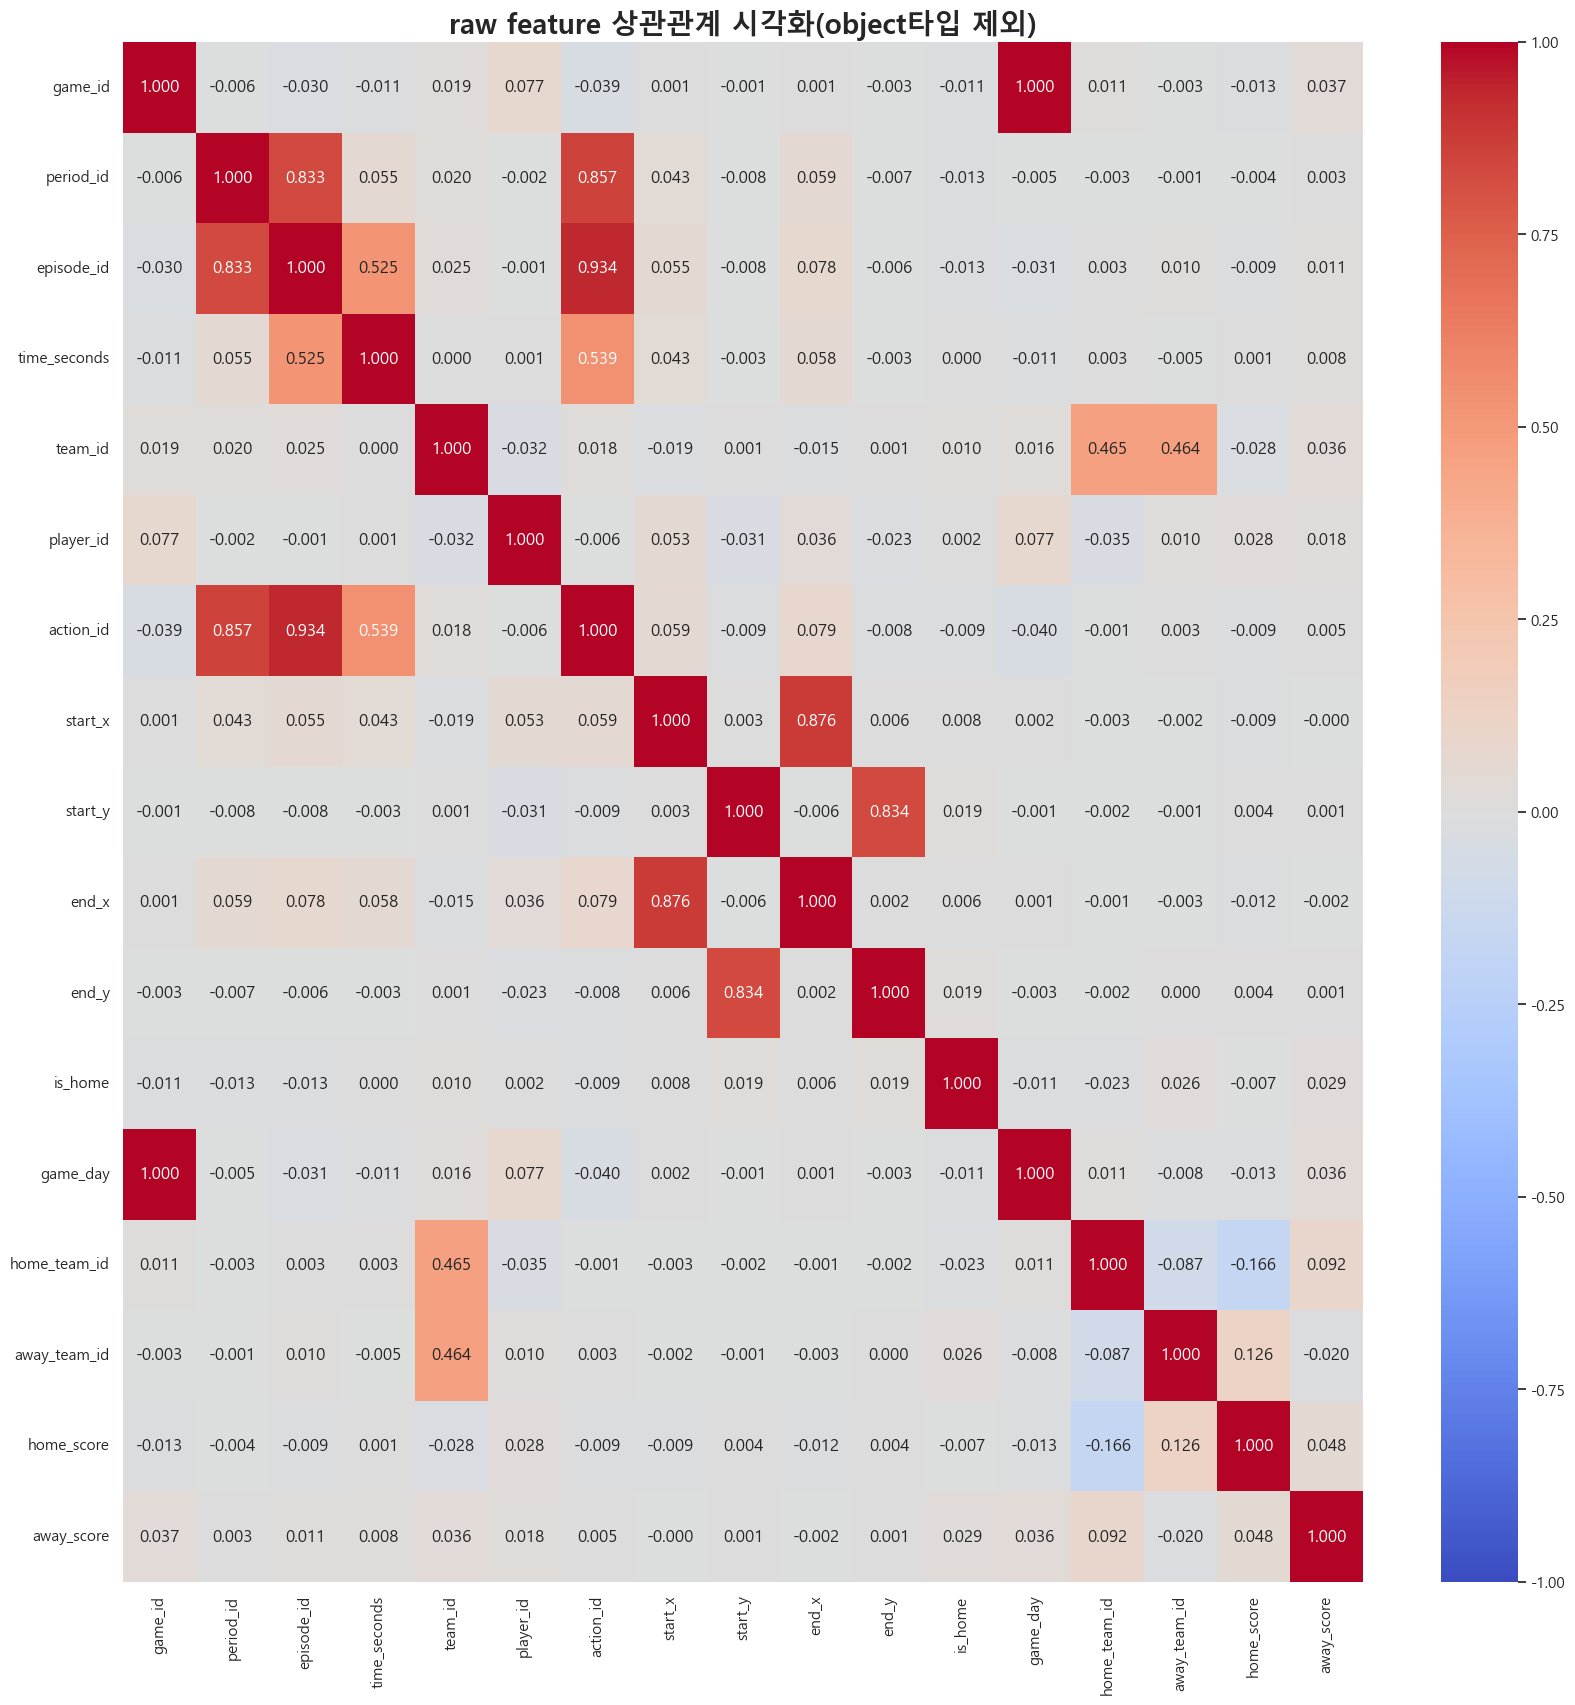

In [97]:
# 피처들의 상관관계 시각화
corr_mat = df.drop(obj, axis=1).corr()

plt.figure(figsize=(20, 20))
sns.heatmap(corr_mat, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm')
plt.title('raw feature 상관관계 시각화(object타입 제외)', weight='bold', fontsize=20)
plt.show()

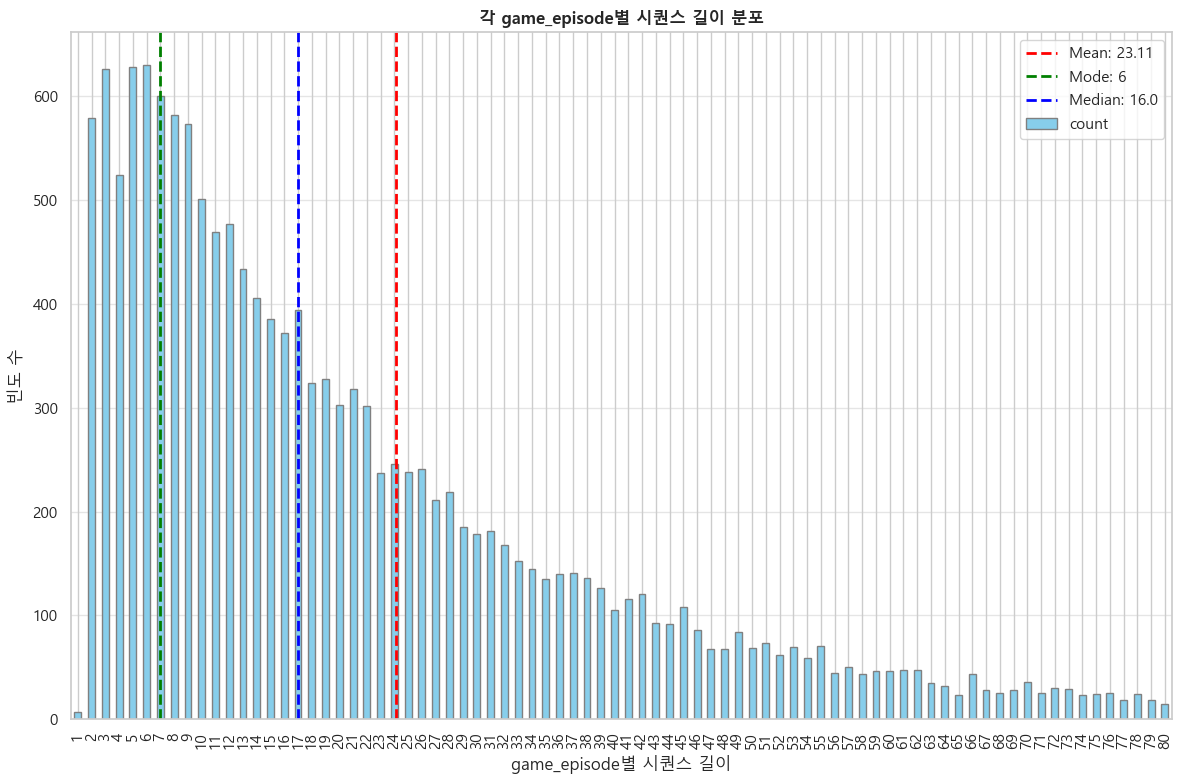

Mean: 23.111
Mode: 6
Max_length: 270
Min_length: 1
대부분의 각 episode는 2개 이상의 이벤트가 발생함


In [98]:
# game_episode별 데이터 길이 분포
ge_length = df.groupby('game_episode')['game_id'].count()

# 길이별 빈도수 계산
length_dist = ge_length.value_counts().sort_index()[:80] # 상위 80개까지

ge_mean = ge_length.mean()
ge_median = ge_length.median()
ge_mode = length_dist.idxmax()

# 막대 그래프 그리기
length_dist.plot(kind='bar', figsize=(12, 8), color='skyblue', edgecolor='gray')
# 평균선 (빨간 점선)
plt.axvline(x=ge_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {ge_mean:.2f}')
# 최빈값선 (초록 점선)
plt.axvline(x=ge_mode, color='green', linestyle='--', linewidth=2, label=f'Mode: {ge_mode}')
# 중앙값선 (파란 점선)
plt.axvline(x=ge_median, color='blue', linestyle='--', linewidth=2, label=f'Median: {ge_median}')


plt.grid(axis='y', alpha=0.5)
plt.legend() # 범례 표시
plt.title('각 game_episode별 시퀀스 길이 분포', weight='bold')
plt.xlabel('game_episode별 시퀀스 길이')
plt.ylabel('빈도 수')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Mean: {ge_mean:.3f}')
print(f'Mode: {ge_mode}')
print(f'Max_length: {ge_length.max()}')
print(f'Min_length: {ge_length.min()}')

print('대부분의 각 episode는 2개 이상의 이벤트가 발생함')

>>> 선택된 에피소드: ['126283_20' '126283_21' '126283_22' '126283_23' '126283_24' '126283_25'
 '126283_26' '126283_27' '126283_28' '126283_29']


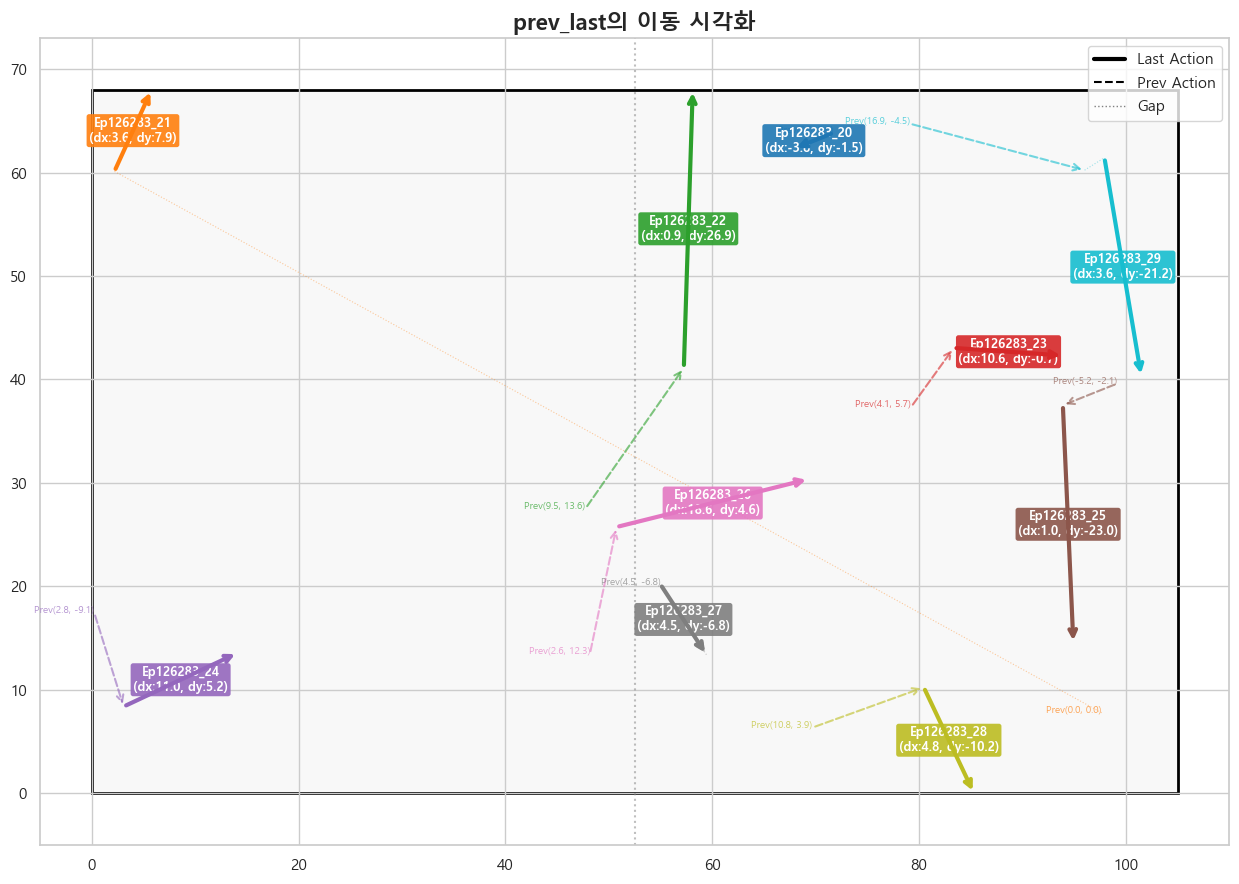

하늘색 화살표는 이전 end 위치와 마지막 start 위치가 다름


In [99]:
def visualize_vectors_fast(df, sample_n=5, specific_episodes=None, width=105, height=68):
    sort_cols = ['game_episode']

    if 'time_seconds' in df.columns: sort_cols.append('time_seconds')
    elif 'frame' in df.columns: sort_cols.append('frame')
    
    df_sorted = df.sort_values(by=sort_cols).reset_index(drop=True)
    is_last_row = df_sorted['game_episode'] != df_sorted['game_episode'].shift(-1)
    has_prev_row = df_sorted['game_episode'] == df_sorted['game_episode'].shift(1)
    has_movement = (df_sorted['start_x'] != df_sorted['end_x']) | (df_sorted['start_y'] != df_sorted['end_y'])
    target_mask = is_last_row & has_prev_row & has_movement
    target_episode_ids = df_sorted.loc[target_mask, 'game_episode'].unique()

    if specific_episodes is not None:
        selected_episodes = [ep for ep in specific_episodes if ep in target_episode_ids]
    else:
        selected_episodes = target_episode_ids[10:20]

    print(f">>> 선택된 에피소드: {selected_episodes}")

    # 3. 그래프 그리기 (여기서부터는 선택된 소수만 그리므로 빠름)
    fig, ax = plt.subplots(figsize=(14, 9))
    
    pitch = patches.Rectangle((0, 0), width, height, linewidth=2, edgecolor='black', facecolor='#F8F8F8', zorder=0)
    ax.add_patch(pitch)
    ax.axvline(x=width/2, color='gray', linestyle=':', alpha=0.5)

    try:
        colormap = plt.colormaps['tab10']
    except AttributeError:
        colormap = plt.get_cmap('tab10')

    # 선택된 에피소드 데이터만 빠르게 추출하기 위해 isin 사용
    subset = df_sorted[df_sorted['game_episode'].isin(selected_episodes)]

    for i, ep_id in enumerate(selected_episodes):
        # 이미 추출된 subset에서 가져오므로 빠름
        group = subset[subset['game_episode'] == ep_id]
        
        last = group.iloc[-1]
        prev = group.iloc[-2]
        
        last_dx = last['end_x'] - last['start_x']
        last_dy = last['end_y'] - last['start_y']
        prev_dx = prev['end_x'] - prev['start_x']
        prev_dy = prev['end_y'] - prev['start_y']
        
        color = colormap(i % 10)
        
        # [Prev] 점선
        ax.annotate("", xy=(prev['end_x'], prev['end_y']), xytext=(prev['start_x'], prev['start_y']),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5, ls='--', alpha=0.6), zorder=3)
        ax.text(prev['start_x'], prev['start_y'], f"Prev({prev_dx:.1f}, {prev_dy:.1f})", 
                fontsize=7, color=color, alpha=0.7, ha='right')

        # [Last] 실선
        ax.annotate("", xy=(last['end_x'], last['end_y']), xytext=(last['start_x'], last['start_y']),
                    arrowprops=dict(arrowstyle="->", color=color, lw=3.0, ls='-'), zorder=4)
        
        mid_x = (last['start_x'] + last['end_x']) / 2
        mid_y = (last['start_y'] + last['end_y']) / 2
        label = f"Ep{ep_id}\n(dx:{last_dx:.1f}, dy:{last_dy:.1f})"
        ax.text(mid_x, mid_y, label, fontsize=9, color='white', fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.9, edgecolor='none'))

        # Gap
        ax.plot([prev['end_x'], last['start_x']], [prev['end_y'], last['start_y']],
                color=color, linestyle=':', linewidth=0.8, alpha=0.4)

    ax.set_title(f'prev_last의 이동 시각화', fontsize=16, fontweight='bold')
    legend_elements = [
        Line2D([0], [0], color='black', lw=3, ls='-', label='Last Action'),
        Line2D([0], [0], color='black', lw=1.5, ls='--', label='Prev Action'),
        Line2D([0], [0], color='gray', lw=1, ls=':', label='Gap')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    ax.set_xlim(-5, width + 5)
    ax.set_ylim(-5, height + 5)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

# 실행
visualize_vectors_fast(df, sample_n=5)
print('하늘색 화살표는 이전 end 위치와 마지막 start 위치가 다름')

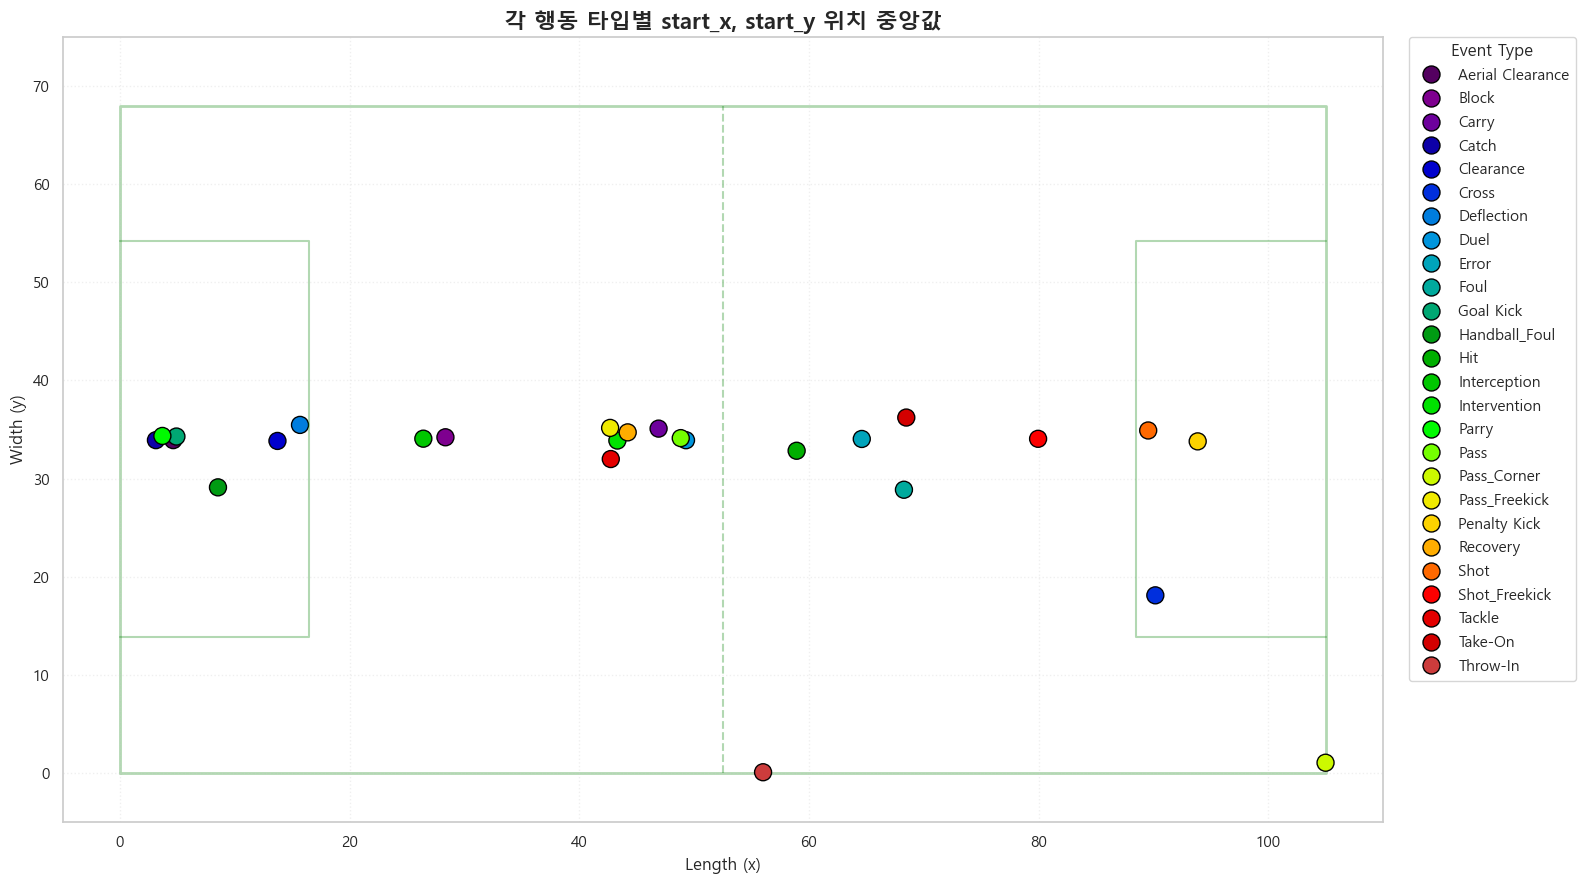

각 타입별로 공격, 수비, 중앙으로 구역을 나눌 수 있음


In [100]:
# 각  행동 타입별 x, y 위치 시각화
median_position = df.groupby('type_name')[['start_x', 'start_y']].median().reset_index()


fig, ax = plt.subplots(figsize=(16, 9))

# 경기장 라인 그리기
# 외곽선
ax.plot([0, 0, 105, 105, 0], [0, 68, 68, 0, 0], color='green', linewidth=2, zorder=0, alpha=0.3)
# 중앙선
ax.plot([52.5, 52.5], [0, 68], color='green', linestyle='--', alpha=0.3)
# 페널티 박스
ax.plot([0, 16.5, 16.5, 0], [13.84, 13.84, 54.16, 54.16], color='green', alpha=0.3)
ax.plot([105, 88.5, 88.5, 105], [13.84, 13.84, 54.16, 54.16], color='green', alpha=0.3)

n_colors = len(df['type_name'].unique())

# 개수만큼 색상 자동 생성
palette = sns.color_palette("nipy_spectral", n_colors)

# 4. 산점도 그리기 (핵심)
sns.scatterplot(
    data=median_position,
    x='start_x',
    y='start_y',
    hue='type_name',
    palette=palette,
    s=150,           
    edgecolor='black',  
    ax=ax              
)

# 범례 설정
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title='Event Type')
plt.title("각 행동 타입별 start_x, start_y 위치 중앙값", fontsize=16, weight='bold')
plt.xlabel("Length (x)", fontsize=12)
plt.ylabel("Width (y)", fontsize=12)
plt.xlim(-5, 110)
plt.ylim(-5, 75)
plt.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout() # 여백 자동 조정
plt.show()

print('각 타입별로 공격, 수비, 중앙으로 구역을 나눌 수 있음')

In [101]:
# 각 type_name별 x 좌표를(35 and 75) 기준으로 수비, 중앙, 공격으로 type을 분류
clf = {'defense': [], 'middle': [], 'offense': []}
for name, x, y in median_position.values:
    if x < 35:
        clf['defense'].append(name)
    elif x < 70:
        clf['middle'].append(name)
    else:
        clf['offense'].append(name)

for key in clf.keys():
    print(clf[key])

['Aerial Clearance', 'Block', 'Catch', 'Clearance', 'Deflection', 'Goal Kick', 'Handball_Foul', 'Interception', 'Parry']
['Carry', 'Duel', 'Error', 'Foul', 'Hit', 'Intervention', 'Pass', 'Pass_Freekick', 'Recovery', 'Tackle', 'Take-On', 'Throw-In']
['Cross', 'Pass_Corner', 'Penalty Kick', 'Shot', 'Shot_Freekick']


=== 계산된 중앙값 데이터 (상위 5개) ===
type_name
Pass_Corner      30.627012
Goal Kick        25.213595
Cross            24.838374
Shot_Freekick    23.517054
Clearance        18.439430
Name: dist, dtype: float64


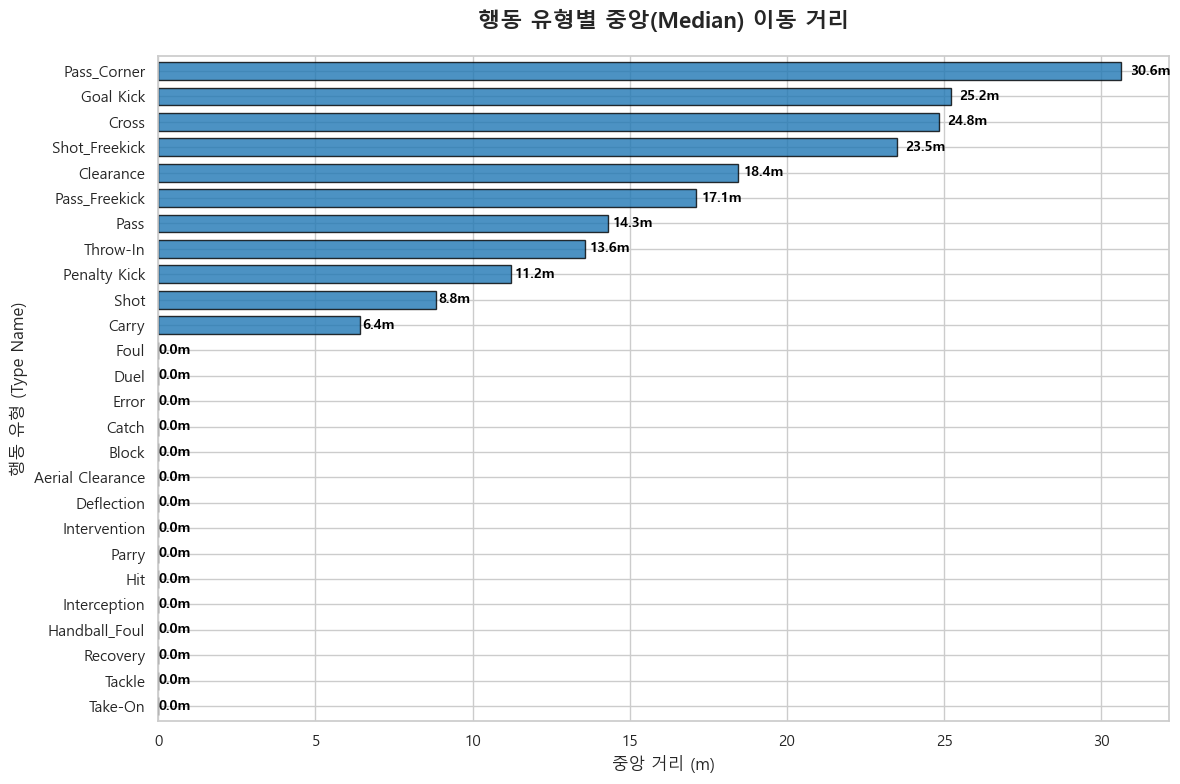

In [102]:
df['dist'] = np.sqrt((df['end_x'] - df['start_x'])**2 + (df['end_y'] - df['start_y'])**2)
median_dist_per_type = df.groupby('type_name')['dist'].median().sort_values(ascending=False)

print("=== 계산된 중앙값 데이터 (상위 5개) ===")
print(median_dist_per_type.head())

sns.set_theme(style="whitegrid", 
              rc={"axes.unicode_minus":False, "font.family": "Malgun Gothic"})

plt.figure(figsize=(12, 8))

ax = median_dist_per_type.plot(kind='barh', color='#1f77b4', edgecolor='black', alpha=0.8, width=0.7)

plt.title('행동 유형별 중앙(Median) 이동 거리', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('중앙 거리 (m)', fontsize=12)
plt.ylabel('행동 유형 (Type Name)', fontsize=12)

plt.gca().invert_yaxis()

for i, v in enumerate(median_dist_per_type):
    ax.text(v + (v * 0.01), i, f'{v:.1f}m', color='black', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [103]:
# 각 행동별 결과
print(df.groupby('type_name')['result_name'].unique())
print('특정 행동에 따라 결과가 달라짐')

type_name
Aerial Clearance                           [Unsuccessful, Successful]
Block                                                           [nan]
Carry                                                           [nan]
Catch                                                           [nan]
Clearance                                                       [nan]
Cross                                      [Unsuccessful, Successful]
Deflection                                                      [nan]
Duel                                       [Successful, Unsuccessful]
Error                                                           [nan]
Foul                                                    [Yellow_Card]
Goal Kick                                  [Successful, Unsuccessful]
Handball_Foul                                                   [nan]
Hit                                                             [nan]
Interception                                                    [nan]
Interventi

In [104]:
# 각 선수별 통계 데이터 생성 함수
def get_player_map(df):
    # 전체 데이터에서 dx, dy를 구함
    df['dx'] = df['end_x'] - df['start_x']
    df['dy'] = df['end_y'] - df['start_y']

    player_stats = df.groupby('player_id').agg(
        player_mean_dx = ('dx', 'mean'),         # dx 평균
        player_mean_dy = ('dy', 'mean'),         # dy 평균

        player_max_dx  = ('dx', 'max'),          # dx 최댓값
        player_max_dy  = ('dy', 'max'),          # dy 최댓값

        player_min_dx  = ('dx', 'min'),          # dx 최솟값
        player_min_dy  = ('dy', 'min'),          # dy 최솟값

        player_start_x = ('start_x', 'median'),  # start_x 중앙값
        player_start_y = ('start_y', 'median'),  # start_y 중앙값
    )
    # 각 선수들의 최대 이동 범위
    player_stats['dx_range'] = player_stats['player_max_dx'] - player_stats['player_min_dx']
    player_stats['dy_range'] = player_stats['player_max_dy'] - player_stats['player_min_dy']

    # new player의 경우 평균값으로
    global_stats = player_stats.mean().to_dict()
    
    # 딕셔너리 변환
    stats_dict = player_stats.to_dict('index')

    # global 값 추가
    stats_dict['global'] = global_stats
    return stats_dict

In [105]:
# 각 팀별 통계 데이터 생성 함수
def get_team_map(df):
    team_stats = df.groupby('team_id').agg(
        team_start_x = ('start_x', 'median'), # start_x 중앙값
        team_start_y = ('start_y', 'median'), # start_y 중앙값
    )

    # new team의 경우 평균값
    global_stats = team_stats.median().to_dict()
    
    # 딕셔너리 변환
    stats_dict = team_stats.to_dict('index')

    # global 값 추가
    stats_dict['global'] = global_stats

    return stats_dict

In [106]:
# 경기장을 5 x 5 grid로 나눠서 선수들의 위치에 따라 dx, dy값의 평균을 생성하는 함수
def get_player_grid_map(df, x_bins=5, y_bins=5):
    data = df.copy()

    PITCH_X_MAX, PITCH_Y_MAX = 105.0, 68.0
    # 공격 방향을 home(왼쪽->오른쪽), away(오른쪽->왼쪽)에 따라 변경
    data['norm_start_x'] = np.where(data['is_home'], data['start_x'], PITCH_X_MAX - data['start_x'])
    data['norm_start_y'] = np.where(data['is_home'], data['start_y'], PITCH_Y_MAX - data['start_y'])
    data['norm_end_x']   = np.where(data['is_home'], data['end_x'], PITCH_X_MAX - data['end_x'])
    data['norm_end_y']   = np.where(data['is_home'], data['end_y'], PITCH_Y_MAX - data['end_y'])

    # Grid Zone 인덱스 생성 (0~4)
    data['zone_x_idx'] = pd.cut(data['norm_start_x'], bins=x_bins, labels=False)
    data['zone_y_idx'] = pd.cut(data['norm_start_y'], bins=y_bins, labels=False)

    #  타겟 변수 계산
    data['dx'] = data['norm_end_x'] - data['norm_start_x']
    data['dy'] = data['norm_end_y'] - data['norm_start_y']

    # grid map 생성
    grid_stats = data.groupby(['player_id', 'zone_x_idx', 'zone_y_idx'])[['dx', 'dy']].mean().to_dict('index')

    # 데이터가 없는 경우 넣을 값 생성
    global_stats = data.groupby('player_id')[['dx', 'dy']].mean().to_dict('index')

    return grid_stats, global_stats

In [107]:
# field의 모든 좌표에서 dx, dy와 가장 연관이 높은 좌표 2개를 찾는 함수
def get_correlation_point(df, target_col):
    df['dx'] = df['end_x'] - df['start_x']
    df['dy'] = df['end_y'] - df['start_y']

    starts = df[['start_x', 'start_y']].values
    target = df[target_col].values

    target_mean = np.mean(target)
    target_centered = target - target_mean
    target_norm = np.linalg.norm(target_centered)

    # target값의 변화가 없는 경우
    if target_norm == 0:
        return [(0, 0), (0, 0)]
    
    # 격자점 생성 (0~105, 0~68)
    X_grid, Y_grid = np.meshgrid(np.arange(106), np.arange(69))
    grid_points = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T

    correlations = []

    for gx, gy in tqdm(grid_points, desc=f'search point {target_col}'):
        dists = np.sqrt((starts[:, 0] - gx)**2 + (starts[:, 1] - gy)**2)

        # 상관계수 수동 계산
        dist_mean = np.mean(dists)
        dist_centered = dists - dist_mean
        dist_norm = np.linalg.norm(dist_centered)

        if dist_norm == 0: corr = 0.0
        else: corr = np.dot(dist_centered, target_centered) / (dist_norm * target_norm)
            
        correlations.append(corr)

    # 결과 정렬 및 추출
    correlations = np.array(correlations)

    # 가장 높은 양의 상관관계 인덱스
    max_idx = np.argmax(correlations)

    # 가장 높은 음의 상관관계 인덱스
    min_idx = np.argmin(correlations)
    
    # 좌표 반환
    best_pos_point = tuple(grid_points[max_idx])
    best_neg_point = tuple(grid_points[min_idx])

    return [best_pos_point, best_neg_point]

In [108]:
# 각 타입 거리의 중앙값을 구하는 함수
def get_type_med(df):
    temp = df.copy()

    temp['start_x'] /= 105
    temp['start_y'] /= 68
    temp['end_x']   /= 105
    temp['end_y']   /= 68

    dx = (temp['end_x'] - temp['start_x'])
    dy = (temp['end_y'] - temp['start_y'])

    temp['dist'] = np.sqrt(dx**2 + dy**2)

    median_map = temp.groupby('type_name')['dist'].median().to_dict()

    return median_map

In [109]:
# feature 생성 함수 
def create_feature(raw_df, player_map, team_map, grid_map, global_map, point, type_med, window=3, is_train=True):
    df = raw_df.copy() # 원본 데이터 복사

    df['result_name'] = df['result_name'].fillna('Unknown') # result_name의 nan -> "Unknown"

    # 각 x, y 크기 정규화(0 <= x,y <= 1)
    df['start_x'] /= 105.0; df['end_x'] /= 105.0
    df['start_y'] /= 68.0;  df['end_y'] /= 68.0

    # game_episode, time_seconds 순서로 정렬
    df = df.sort_values(by=['game_episode', 'time_seconds']).reset_index(drop=True)

    feats = [] # 각 game_episode 별로 생성한 feature들의 묶음을 저장할 배열

    # df를 game_episode로 그룹화
    grouped = df.groupby('game_episode')

    for game_episode, group in tqdm(grouped, desc='Feature Extraction'):
        feature_dict = {} # 각 game_episode 마다 생성한 feature를 저장할 딕셔너리
        group = group.reset_index(drop=True)

        feature_dict['game_episode'] = game_episode # 현재 game_episode

        # 가장 마지막 이벤트에 대한 데이터
        last_row = group.iloc[-1] # 마지막 행을 추출

        feature_dict['last_start_x']      = last_row['start_x']      # x좌표
        feature_dict['last_start_y']      = last_row['start_y']      # y좌표
        feature_dict['last_player_id']    = last_row['player_id']    # 선수 ID
        feature_dict['last_team_id']      = last_row['team_id']      # 팀 ID
        feature_dict['last_type_name']    = last_row['type_name']    # 행동 타입
        feature_dict['last_result_name']  = last_row['result_name']  # 성공 여부
        feature_dict['last_time_seconds'] = last_row['time_seconds'] # 시간
        feature_dict['last_is_home']      = last_row['is_home']      # 홈 팀 여부

        # 이전 이벤트에 대한 데이터
        past_group = group.iloc[:-1].copy() # 마지막 이벤트를 제외한 나머지 그룹

        if len(past_group) > 0: # 시퀀스의 길이가 1보다 큰 경우만
            prev_row = past_group.iloc[-1] # 마지막 시점 이전의 데이터

            # 마지막 시작 위치와 이전 종료 위치의 차이(x, y)
            feature_dict['prev_last_dx']   = last_row['start_x'] - prev_row['end_x'] # x 차이
            feature_dict['prev_last_dy']   = last_row['start_y'] - prev_row['end_y'] # y 차이
            feature_dict['prev_last_dist'] = np.sqrt(feature_dict['prev_last_dx']**2 + feature_dict['prev_last_dy']**2) # 거리 계산

            # 이전 이벤트에 대한 데이터
            feature_dict['prev_start_x']      = prev_row['start_x']      # start x좌표
            feature_dict['prev_start_y']      = prev_row['start_y']      # start y좌표
            feature_dict['prev_end_x']        = prev_row['end_x']        # end x좌표
            feature_dict['prev_end_y']        = prev_row['end_y']        # end y좌표
            feature_dict['prev_player_id']    = prev_row['player_id']    # 선수 ID
            feature_dict['prev_team_id']      = prev_row['team_id']      # 팀 ID
            feature_dict['prev_type_name']    = prev_row['type_name']    # 행동 타입
            feature_dict['prev_result_name']  = prev_row['result_name']  # 성공여부
            feature_dict['prev_time_seconds'] = prev_row['time_seconds'] # 시간
            feature_dict['prev_is_home']      = prev_row['is_home']      # 홈 팀 여부

            # feature 조합 및 연산을 통한 데이터 생성
            feature_dict['prev_dx']    = prev_row['end_x'] - prev_row['start_x'] # 이전 이벤트의 dx
            feature_dict['prev_dy']    = prev_row['end_y'] - prev_row['start_y'] # 이전 이벤트의 dy
            feature_dict['last_dt']    = last_row['time_seconds'] - prev_row['time_seconds'] # 마지막/이전 이벤트의 시간 차이
            feature_dict['prev_dist']  = np.sqrt(feature_dict['prev_dx']**2 + feature_dict['prev_dy']**2) # 이전 이벤트의 거리
            feature_dict['prev_speed'] = feature_dict['prev_dist'] / (feature_dict['last_dt'] + 1e-8) # 이전 이벤트의 속도
            feature_dict['prev_sin']   = feature_dict['prev_dy'] / (feature_dict['prev_dist'] + 1e-8) # 이전 이벤트의 sin
            feature_dict['prev_cos']   = feature_dict['prev_dx'] / (feature_dict['prev_dist'] + 1e-8) # 이전 이벤트의 cos

            # prev의 dx, dy에 시간을 나눔
            feature_dict['prev_dx_dt_div'] = feature_dict['prev_dx'] / (feature_dict['last_dt'] + 1e-8)
            feature_dict['prev_dy_dt_div'] = feature_dict['prev_dy'] / (feature_dict['last_dt'] + 1e-8)

            # prev의 dx, dy에 속도를 곱함
            feature_dict['prev_dx_speed'] = feature_dict['prev_dx'] * feature_dict['prev_speed']
            feature_dict['prev_dy_speed'] = feature_dict['prev_dy'] * feature_dict['prev_speed']

            # prev의 dx, dy abs값에 속도를 곱함
            feature_dict['prev_dx_speed_abs'] = abs(feature_dict['prev_dx']) * feature_dict['prev_speed']
            feature_dict['prev_dy_speed_abs'] = abs(feature_dict['prev_dy']) * feature_dict['prev_speed']

            # prev_last의 dx, dy에 시간을 나눔
            feature_dict['prev_last_x_vel'] = feature_dict['prev_last_dx'] / (feature_dict['last_dt'] + 1e-8)
            feature_dict['prev_last_y_vel'] = feature_dict['prev_last_dy'] / (feature_dict['last_dt'] + 1e-8)
            
            # prev_last의 dx, dy에 시간을 곱함
            feature_dict['prev_last_x_dt'] = feature_dict['prev_last_dx'] * feature_dict['last_dt']
            feature_dict['prev_last_y_dt'] = feature_dict['prev_last_dy'] * feature_dict['last_dt']

            # player_map을 이용한 feature 생성
            last_player_map = player_map.get(last_row['player_id'], player_map['global'])
            prev_player_map = player_map.get(prev_row['player_id'], player_map['global'])

            feature_dict['last_player_dy'] = last_player_map['player_mean_dy'] # 마지막 선수의 dy 평균
            feature_dict['prev_player_dy'] = prev_player_map['player_mean_dy'] # 이전 선수의 dy 평균

            feature_dict['ll_player_dy']         = last_player_map['player_start_y'] - feature_dict['last_start_y'] # 
            feature_dict['prev_player_dx_diff']  = feature_dict['prev_last_dx'] - prev_player_map['player_mean_dx'] # (last_start_x - prev_end_x) - (player_mean_start_y)
            feature_dict['plsx_pey_diff']        = last_player_map['player_start_x'] - feature_dict['prev_end_y']   # 마지막 선수의 평균 start_x - 이전 선수의 end_y

            feature_dict['last_player_dy_range'] = last_player_map['dy_range'] # 마지막 선수의 dy 범위
            
            # 마지막 선수의 dy/dx * 이전 선수의 dy/dx
            feature_dict['player_dy_dx_div']     = (last_player_map['player_mean_dy'] * prev_player_map['player_mean_dy']) / (last_player_map['player_mean_dx'] * prev_player_map['player_mean_dx'])
            
            # grid 데이터
            last_x_idx = min(int(feature_dict['last_start_x']*5), 4) # x 위치
            last_y_idx = min(int(feature_dict['last_start_y']*5), 4) # y 위치
            last_p     = feature_dict['last_player_id']              # 선수 번호

            key = (last_p, last_x_idx, last_y_idx) # key

            if grid_map and key in grid_map: # key의 정보가 있는 경우
                stats = grid_map[key]
                feature_dict['grid_dx'] = stats['dx']
                feature_dict['grid_dy'] = stats['dy']
            elif global_map and last_p in global_map: # 선수 정보만 있는 경우
                stats = global_map[last_p]
                feature_dict['grid_dx'] = stats['dx']
                feature_dict['grid_dy'] = stats['dy']
            else: # 둘다 없는 경우
                feature_dict['grid_dx'] = 0.0
                feature_dict['grid_dy'] = 0.0
            
            feature_dict['last_result_grid_dx'] = f"{feature_dict['last_result_name']}_{feature_dict['grid_dx']}" # 마지막 결과와 grid_dx
            feature_dict['prev_type_grid_dy']   = f"{feature_dict['prev_type_name']}_{feature_dict['grid_dy']}"   # 이전 행동과 grid_dy  
            feature_dict['prev_type_grid_dx']   = f"{feature_dict['prev_type_name']}_{feature_dict['grid_dx']}"   # 이전 행동과 grid_dx

            # team에 대한 데이터
            last_team_map = team_map.get(last_row['team_id'], team_map['global'])
            prev_team_map = team_map.get(prev_row['team_id'], team_map['global'])

            feature_dict['last_team_start_x'] = last_team_map['team_start_x']
            feature_dict['prev_team_start_x'] = prev_team_map['team_start_x']

            # quantile 정보
            feature_dict['g_start_x_75'] = group['start_x'].quantile(0.75)
            feature_dict['g_start_y_25'] = group['start_y'].quantile(0.25)

            # 이동 평균
            if len(past_group) >= window: # window 크기보다 큰 경우만
                past_group['step_dx']    = past_group['end_x'] - past_group['start_x']
                past_group['step_dy']    = past_group['end_y'] - past_group['start_y']
                past_group['step_dist']  = np.sqrt(past_group['step_dx']**2 + past_group['step_dy']**2)
                past_group['step_sin']   = past_group['step_dy'] / (past_group['step_dist'] + 1e-8)
                past_group['step_cos']   = past_group['step_dx'] / (past_group['step_dist'] + 1e-8)
                past_group['time_diff']  = past_group['time_seconds'].diff().fillna(0)
                past_group['step_speed'] = np.where(past_group['time_diff'] > 0, past_group['step_dist'] / past_group['time_diff'], 0)

                # 과거의 마지막 window 만큼의 평균
                feature_dict['roll_start_x_mean'] = past_group['start_x'].tail(window).mean()
                feature_dict['roll_start_y_mean'] = past_group['start_y'].tail(window).mean()
                feature_dict['roll_end_x_mean']   = past_group['end_x'].tail(window).mean()
                feature_dict['roll_end_y_mean']   = past_group['end_y'].tail(window).mean()
                feature_dict['roll_dx_mean']      = past_group['step_dx'].tail(window).mean()
                feature_dict['roll_dy_mean']      = past_group['step_dy'].tail(window).mean()
                feature_dict['roll_dist_mean']    = past_group['step_dist'].tail(window).mean()
                feature_dict['roll_sin_mean']     = past_group['step_sin'].tail(window).mean()
                feature_dict['roll_cos_mean']     = past_group['step_cos'].tail(window).mean()
                feature_dict['roll_speed_med']    = past_group['step_speed'].tail(window).median()

                # 과거의 마지막 window 만큼의 변동계수
                feature_dict['roll_dx_cv']       = past_group['step_dx'].tail(window).std() / (feature_dict['roll_dx_mean'] + 1e-6)
                feature_dict['roll_dy_cv']       = past_group['step_dy'].tail(window).std() / (feature_dict['roll_dy_mean'] + 1e-6)
                feature_dict['roll_dist_cv']     = past_group['step_dist'].tail(window).std() / (feature_dict['roll_dist_mean'] + 1e-8)
                feature_dict['roll_speed_cv']    = past_group['step_speed'].tail(window).std() / (feature_dict['roll_speed_med'] + 1e-8)
                feature_dict['roll_sin_cv']      = past_group['step_sin'].tail(window).std() / (feature_dict['roll_sin_mean'] + 1e-8)
                feature_dict['roll_cos_cv']      = past_group['step_cos'].tail(window).std() / (feature_dict['roll_cos_mean'] + 1e-8)

                # window dy 평균 - 이전 dy
                feature_dict['roll_prev_dy']     = feature_dict['roll_dy_mean'] - feature_dict['prev_dy']

                # 벡터 내적
                vec_x_1 = feature_dict['prev_last_dx']
                vec_x_2 = feature_dict['prev_dx']
                vec_y_1 = feature_dict['prev_last_dy']
                vec_y_2 = feature_dict['prev_dy']
                feature_dict['prev_last_dot_prod'] = (vec_x_1 * vec_x_2) + (vec_y_1 * vec_y_2)

                # 이전 그룹의 start_x, start_y의 상관계수
                feature_dict['start_xy_corr'] = past_group['start_x'].corr(past_group['start_y'])

                # quantile 데이터
                feature_dict['pg_dx_25']     = past_group['step_dx'].quantile(0.25)
                feature_dict['pg_dy_25']     = past_group['step_dy'].quantile(0.25)
                feature_dict['pg_dy_75']     = past_group['step_dy'].quantile(0.75)
                feature_dict['window_dx_25'] = past_group['step_dx'].tail(window).quantile(0.25)

            else: # 과거 데이터 부족 시 직전 값
                feature_dict['roll_start_x_mean'] = feature_dict['prev_start_x']
                feature_dict['roll_start_y_mean'] = feature_dict['prev_start_y']
                feature_dict['roll_end_x_mean']   = feature_dict['prev_end_x']
                feature_dict['roll_end_y_mean']   = feature_dict['prev_end_y']
                feature_dict['roll_dx_mean']      = feature_dict['prev_dx']
                feature_dict['roll_dy_mean']      = feature_dict['prev_dy']
                feature_dict['roll_dist_mean']    = feature_dict['prev_dist']
                feature_dict['roll_speed_med']    = feature_dict['prev_speed']
                feature_dict['roll_sin_mean']     = feature_dict['prev_sin']
                feature_dict['roll_cos_mean']     = feature_dict['prev_cos']

                feature_dict['roll_dx_cv']       = 0.0
                feature_dict['roll_dy_cv']       = 0.0
                feature_dict['roll_dist_cv']     = 0.0
                feature_dict['roll_speed_cv']    = 0.0
                feature_dict['roll_sin_cv']      = 0.0
                feature_dict['roll_cos_cv']      = 0.0
                feature_dict['roll_prev_dy']     = np.nan

                feature_dict['prev_last_dot_prod'] = np.nan
                feature_dict['start_xy_corr']      = 0

                feature_dict['pg_dx_25']           = np.nan
                feature_dict['pg_dy_25']           = np.nan
                feature_dict['pg_dy_75']           = np.nan
                feature_dict['window_dx_25']       = np.nan

        else: # 과거 기록 없음
            feature_dict['prev_last_dx']     = 0.0
            feature_dict['prev_last_dy']     = 0.0
            feature_dict['prev_last_dist']   = 0.0

            feature_dict['prev_start_x']      = 0.0
            feature_dict['prev_start_y']      = 0.0
            feature_dict['prev_end_x']        = 0.0
            feature_dict['prev_end_y']        = 0.0
            feature_dict['prev_player_id']    = np.nan
            feature_dict['prev_team_id']      = np.nan
            feature_dict['prev_type_name']    = np.nan
            feature_dict['prev_result_name']  = np.nan
            feature_dict['prev_time_seconds'] = np.nan
            feature_dict['prev_is_home']      = np.nan

            feature_dict['prev_dx']    = 0.0
            feature_dict['prev_dy']    = 0.0
            feature_dict['last_dt']    = 0.0
            feature_dict['prev_dist']  = 0.0
            feature_dict['prev_speed'] = 0.0
            feature_dict['prev_sin']   = 0.0
            feature_dict['prev_cos']   = 0.0

            feature_dict['prev_dx_dt_div'] = 0.0 
            feature_dict['prev_dy_dt_div'] = 0.0

            feature_dict['prev_dx_speed']  = 0.0
            feature_dict['prev_dy_speed']  = 0.0

            feature_dict['prev_dx_speed_abs'] = 0.0 
            feature_dict['prev_dy_speed_abs'] = 0.0

            feature_dict['prev_last_x_vel']   = 0.0
            feature_dict['prev_last_y_vel']   = 0.0

            feature_dict['prev_last_x_dt']    = 0.0
            feature_dict['prev_last_y_dt']    = 0.0

            feature_dict['last_player_dy']       = 0.0
            feature_dict['prev_player_dy']       = 0.0
            feature_dict['ll_player_dy']         = 0.0
            feature_dict['prev_player_dx_diff']  = 0.0 
            feature_dict['plsx_pey_diff']        = 0.0 
            feature_dict['last_player_dy_range'] = 0.0
            feature_dict['player_dy_dx_div']     = 0.0

            feature_dict['grid_dx'] = 0.0
            feature_dict['grid_dy'] = 0.0

            feature_dict['last_result_grid_dx'] = np.nan
            feature_dict['prev_type_grid_dy']   = np.nan
            feature_dict['prev_type_grid_dx']   = np.nan

            feature_dict['last_team_start_x'] = 0.0
            feature_dict['prev_team_start_x'] = 0.0

            # quantile 정보
            feature_dict['g_start_x_75'] = 0.0
            feature_dict['g_start_y_25'] = 0.0

            feature_dict['roll_start_x_mean'] = feature_dict['prev_start_x']
            feature_dict['roll_start_y_mean'] = feature_dict['prev_start_y']
            feature_dict['roll_end_x_mean']   = feature_dict['prev_end_x']
            feature_dict['roll_end_y_mean']   = feature_dict['prev_end_y']
            feature_dict['roll_dx_mean']      = feature_dict['prev_dx']
            feature_dict['roll_dy_mean']      = feature_dict['prev_dy']
            feature_dict['roll_dist_mean']    = feature_dict['prev_dist']
            feature_dict['roll_speed_med']    = feature_dict['prev_speed']
            feature_dict['roll_sin_mean']     = feature_dict['prev_sin']
            feature_dict['roll_cos_mean']     = feature_dict['prev_cos']
        
            feature_dict['roll_dx_cv']       = 0.0
            feature_dict['roll_dy_cv']       = 0.0
            feature_dict['roll_dist_cv']     = 0.0
            feature_dict['roll_speed_cv']    = 0.0
            feature_dict['roll_sin_cv']      = 0.0
            feature_dict['roll_cos_cv']      = 0.0
            feature_dict['roll_prev_dy']     = np.nan
        
            feature_dict['prev_last_dot_prod'] = np.nan
            feature_dict['start_xy_corr']      = 0
        
            feature_dict['pg_dx_25']           = 0.0
            feature_dict['pg_dy_25']           = 0.0
            feature_dict['pg_dy_75']           = 0.0
            feature_dict['window_dx_25']       = 0.0

        # 필드에서 dx, dy와 상관계수가 높은 포인트 4
        for i, (x, y) in enumerate(point):
            x /= 105.0
            y /= 68.0

            dx = feature_dict['last_start_x'] - x
            dy = feature_dict['last_start_y'] - y

            feature_dict[f'field_dx_{i}'] = dx
            feature_dict[f'field_dy_{i}'] = dy

            prev_dx = feature_dict['prev_start_x'] - x
            prev_dy = feature_dict['prev_start_y'] - y

            feature_dict[f'field_dist_{i}'] = np.sqrt(dx**2 + dy**2) # 거리
            feature_dict[f'prev_field_dist_{i}'] = np.sqrt(prev_dx**2 + prev_dy**2) # 이전 위치와의 거리
            feature_dict[f'last_prev_field_dist_diff_{i}'] = feature_dict[f'field_dist_{i}'] - feature_dict[f'prev_field_dist_{i}']

            if i == 1:
                feature_dict[f'field_dx_dt_{i}'] = dx * feature_dict['last_dt']
                feature_dict[f'field_dy_dt_{i}'] = dy * feature_dict['last_dt']
            
            if i < 3:
                feature_dict[f'field_speed_{i}'] = feature_dict[f'field_dist_{i}'] / (feature_dict['last_dt'] + 1e-8)
            
            if i > 0:
                feature_dict[f'prev_field_speed_{i}'] = feature_dict[f'prev_field_dist_{i}'] / (feature_dict['last_dt'] + 1e-8)
            
            if 0 < i < 3:
                feature_dict[f'field_speed_diff_{i}'] = feature_dict[f'field_speed_{i}'] - feature_dict[f'prev_field_speed_{i}']

            if i == 3:
                feature_dict[f'prev_field_dx_speed_{i}'] = prev_dx * feature_dict['prev_speed']
            
        # 벡터 내적
        for i, (x, y) in enumerate(point):
            vec_v_x = feature_dict['prev_dx']
            vec_v_y = feature_dict['prev_dy']

            vec_t_x = x - feature_dict['last_start_x']
            vec_t_y = y - feature_dict['last_start_y']
            
            t_norm = np.sqrt(vec_t_x**2 + vec_t_y**2) + 1e-8
            unit_t_x = vec_t_x / t_norm
            unit_t_y = vec_t_y / t_norm

            feature_dict[f'dot_prod_{i}'] = (vec_v_x * unit_t_x) + (vec_v_y * unit_t_y)

        # 외적 (0 번 좌표에 대해서만)
        vec_v_x = feature_dict['prev_dx']
        vec_v_y = feature_dict['prev_dy']

        vec_t_x = 50 - feature_dict['last_start_x']
        vec_t_y = 68 - feature_dict['last_start_y']

        v_norm  = np.sqrt(vec_v_x**2 + vec_v_y**2) + 1e-8
        t_norm = np.sqrt(vec_t_x**2 + vec_t_y**2) + 1e-8
        unit_t_x = vec_t_x / t_norm
        unit_t_y = vec_t_y / t_norm
        feature_dict['cross_prod_0'] = (vec_v_x * unit_t_y) - (vec_v_y * unit_t_x)
        feature_dict['cos_theta_0'] = feature_dict['dot_prod_0'] / v_norm

        # 중앙관련 
        feature_dict['center_dx'] = (0.5 - feature_dict['last_start_x'])
        feature_dict['center_dy'] = (0.5 - feature_dict['last_start_y'])
        feature_dict['center_dy_abs'] = abs(feature_dict['center_dy'])
        feature_dict['center_dx_abs'] = abs(feature_dict['center_dx'])

        feature_dict['center_dx_dt'] = feature_dict['center_dx'] * feature_dict['last_dt']
        feature_dict['center_dy_dt'] = feature_dict['center_dy'] * feature_dict['last_dt']

        feature_dict['dist_to_center'] = np.sqrt(feature_dict['center_dx']**2 + feature_dict['center_dy']**2) # 중앙까지의 거리

        feature_dict['dist_to_center_speed'] = feature_dict['dist_to_center']  / (feature_dict['prev_speed'] + 1e-8)

        PITCH_LEN_X, PITCH_WID_Y = 105.0, 68.0

        # 규격 정의
        norm_pen_depth = 16.5 / PITCH_LEN_X      # 패널티 박스 깊이
        norm_pen_width_half = (40.32 / 2) / PITCH_WID_Y # 패널티 박스 폭 절반

        pen_box_x_start = 1.0 - norm_pen_depth
        pen_box_y_min = 0.5 - norm_pen_width_half
        pen_box_y_max = 0.5 + norm_pen_width_half

        # 진입 여부 판별
        in_pen_box = 1 if (feature_dict['last_start_x'] >= pen_box_x_start) and (pen_box_y_min <= feature_dict['last_start_y'] <= pen_box_y_max) else 0

        if in_pen_box:
            feature_dict['dist_to_pen_edge'] = 0.0
        else:
            dx_pen = max(0, pen_box_x_start - feature_dict['last_start_x'])
            if feature_dict['last_start_y'] < pen_box_y_min:
                dy_pen = pen_box_y_min - feature_dict['last_start_y']
            elif feature_dict['last_start_y'] > pen_box_y_max:
                dy_pen = feature_dict['last_start_y'] - pen_box_y_max
            else:
                dy_pen = 0
            feature_dict['dist_to_pen_edge'] = np.sqrt(dx_pen**2 + dy_pen**2)
        
        goal_x, goal_y = 1.0, 0.5
        vec_goal_x = goal_x - feature_dict['last_start_x']
        vec_goal_y = goal_y - feature_dict['last_start_y']

        feature_dict['dist_to_goal_center'] = np.sqrt(vec_goal_x**2 + vec_goal_y**2)
        feature_dict['angle_to_goal'] = np.arctan2(vec_goal_y, vec_goal_x)
        post1_y = 0.5 - (3.66 / 68.0)
        post2_y = 0.5 + (3.66 / 68.0)

        vec_p1_x, vec_p1_y = 1.0 - feature_dict['last_start_x'], post1_y - feature_dict['last_start_y']
        vec_p2_x, vec_p2_y = 1.0 - feature_dict['last_start_x'], post2_y - feature_dict['last_start_y']
        angle_p1 = np.arctan2(vec_p1_y, vec_p1_x)
        angle_p2 = np.arctan2(vec_p2_y, vec_p2_x)
        feature_dict['visible_goal_angle'] = abs(angle_p1 - angle_p2)

        # meta 정보
        feature_dict['home_team']  = last_row['home_team_id']
        feature_dict['away_team']  = last_row['away_team_id']
        feature_dict['home_score'] = last_row['home_score']
        feature_dict['away_score'] = last_row['away_score']
        feature_dict['prev_type_result'] = f"{prev_row['type_name']}_{prev_row['result_name']}"

        # nan값이 아닌 경우만
        if pd.notna(feature_dict.get('prev_type_name')) and pd.notna(feature_dict.get('prev_dist')):
            name = feature_dict['prev_type_name']
            prev_dist = feature_dict['prev_dist']
            typical_dist = type_med.get(name, 0)
            feature_dict['type_med_diff'] = prev_dist - typical_dist
        else:
            feature_dict['type_med_diff'] = 0  # 또는 np.nan
    
        if is_train:
            feature_dict['target_dx']  = last_row['end_x'] - last_row['start_x'] # 마지막 x위치 변화
            feature_dict['target_dy']  = last_row['end_y'] - last_row['start_y'] # 마지막 y위치 변화
            feature_dict['true_end_x'] = last_row['end_x'] # 실제 x위치
            feature_dict['true_end_y'] = last_row['end_y'] # 실제 y위치

        feats.append(feature_dict)
    
    return pd.DataFrame(feats)

In [110]:
player_map = get_player_map(df)
team_map = get_team_map(df)
grid_map, global_map = get_player_grid_map(df)
point = get_correlation_point(df,'dy')
point.extend(get_correlation_point(df, 'dx'))
type_med = get_type_med(df)

search point dx: 100%|██████████| 7314/7314 [00:18<00:00, 392.98it/s]


In [111]:
df_data = create_feature(df, player_map, team_map, grid_map, global_map, point, type_med)
num_cols = [i for i in df_data.columns if df_data[i].dtype != 'object']
cat_cols = [i for i in df_data.columns if df_data[i].dtype == 'object']

Feature Extraction: 100%|██████████| 15435/15435 [00:35<00:00, 439.51it/s]


In [112]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder()
df_data[cat_cols] = oe.fit_transform(df_data[cat_cols])

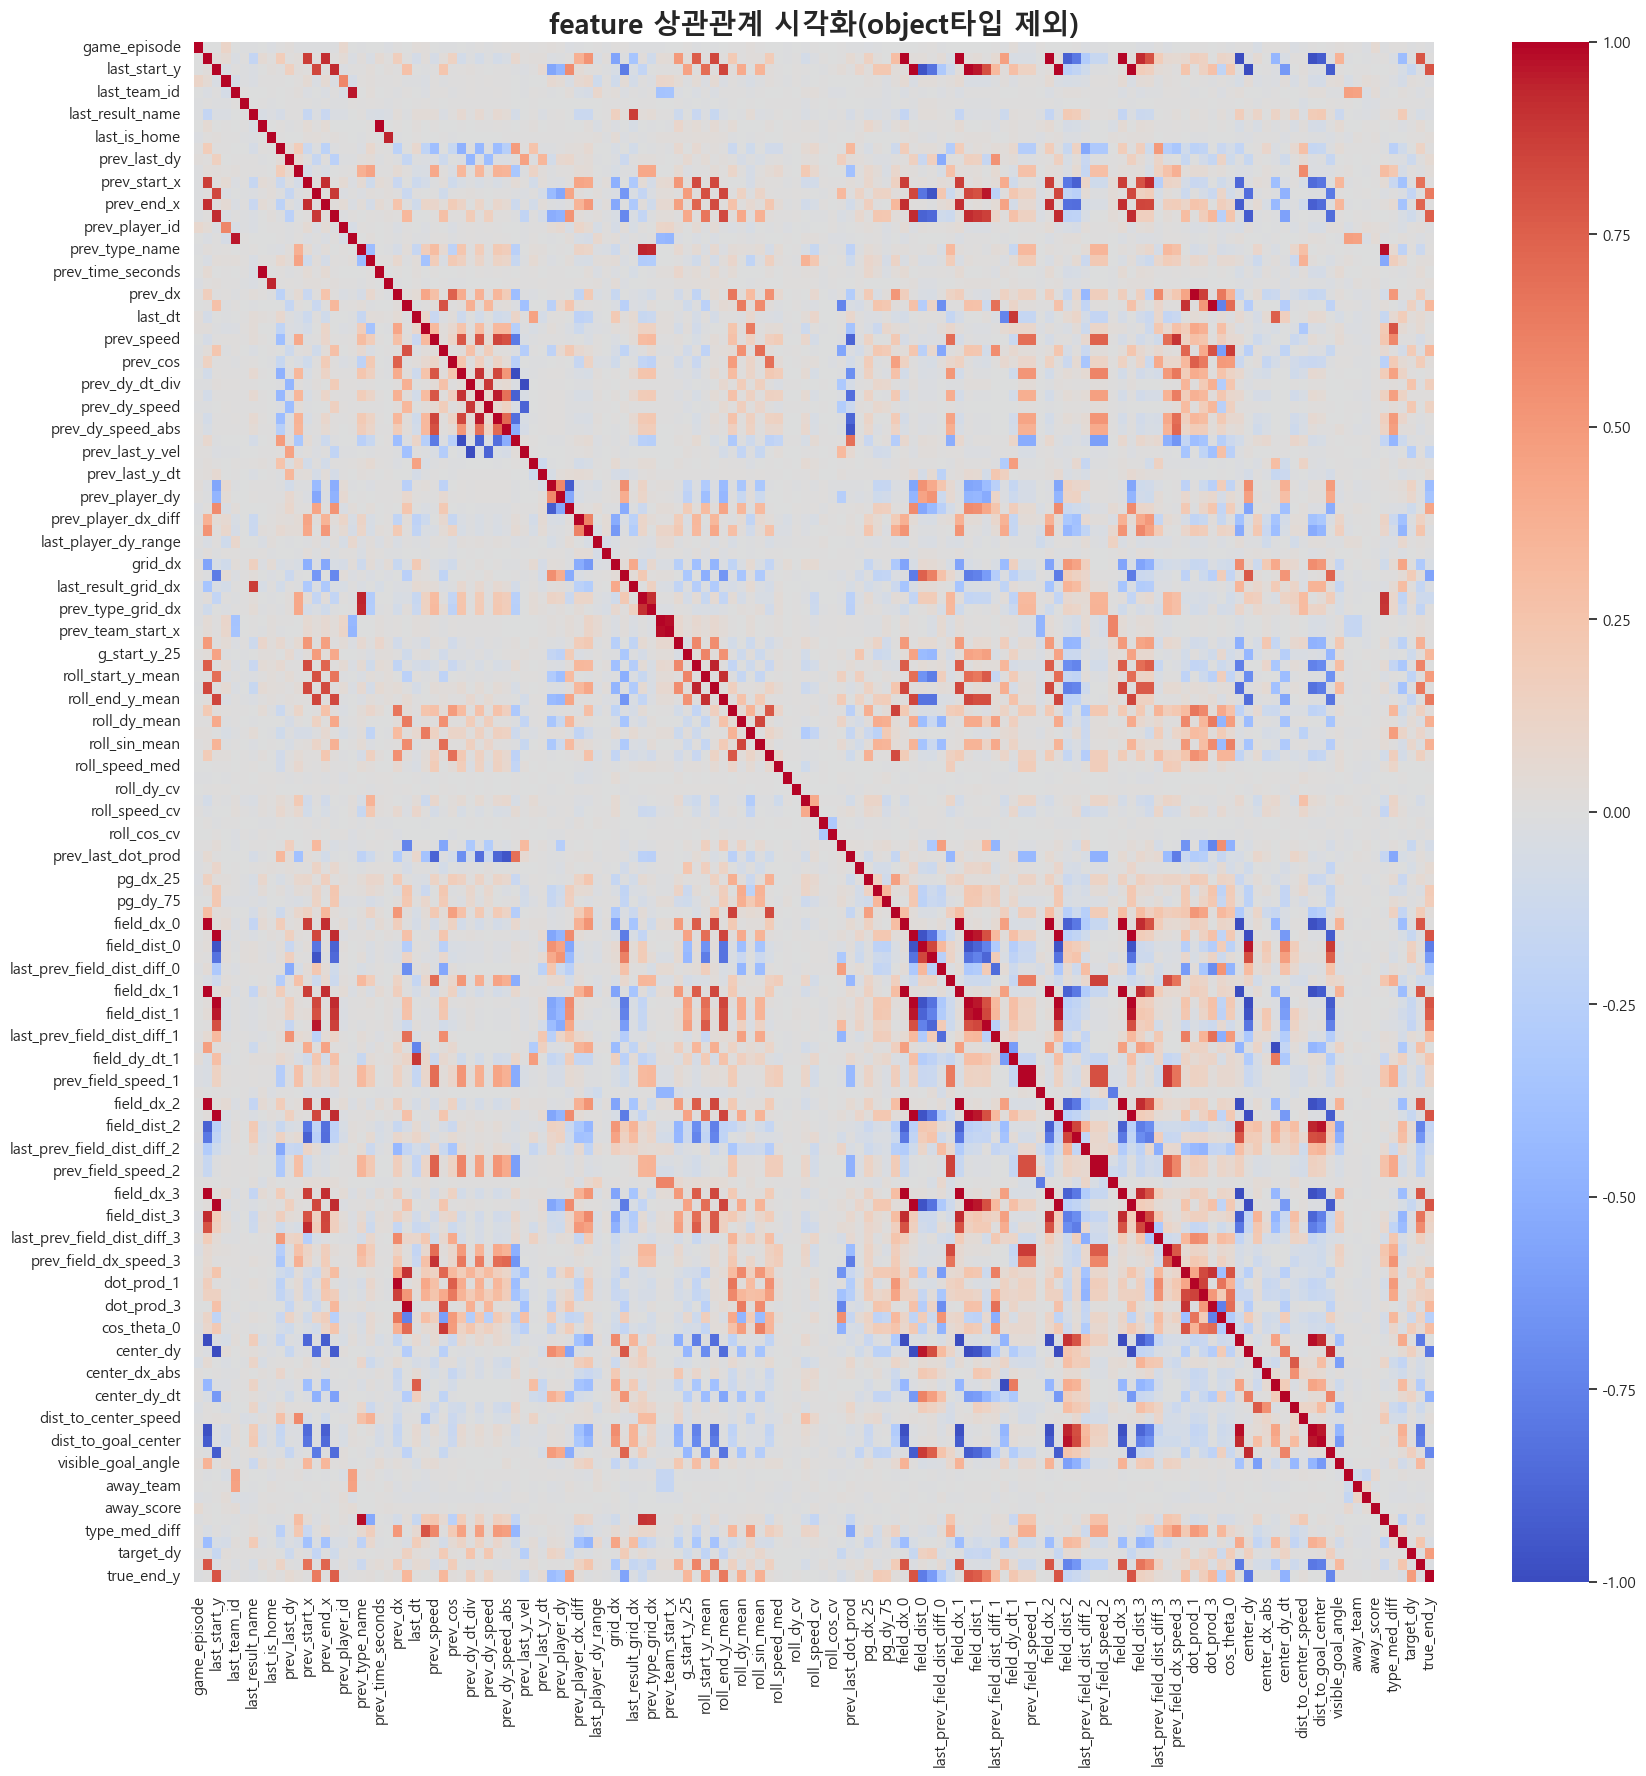

In [113]:
# 피처들의 상관관계 시각화
new_corr_mat = df_data.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(new_corr_mat, vmin=-1, vmax=1, cmap='coolwarm')
plt.title('feature 상관관계 시각화(object타입 제외)', weight='bold', fontsize=20)
plt.show()

In [114]:
new_corr_mat[['target_dx', 'target_dy']].sort_values('target_dx')

,target_dx,target_dy
plsx_pey_diff,-0.467801,-0.030570
field_dist_3,-0.462181,-0.028111
prev_field_dist_3,-0.419363,-0.035646
field_dx_0,-0.409424,-0.013985
field_dx_1,-0.409424,-0.013985
...,...,...
field_dist_2,0.324038,0.052683
dist_to_pen_edge,0.377455,0.014714
center_dx,0.409424,0.013985
grid_dx,0.444872,0.003604


In [115]:
import lightgbm as lgb
def validate_with_lgbm(train_df, val_df, target_col, alpha=0.5, run='mae', model_name="LGBM"):
    drop_cols = ['target_dx', 'target_dy', 'true_end_x', 'true_end_y', 'game_episode']

    if target_col == 'target_dx':
        drop_cols += ['last_player_dy', 'lsx_pey_diff', 'grid_dy', 'visible_goal_angle', 'angle_to_goal', 'type_med_diff']
        drop_cols += ['start_xy_corr', 'g_start_x_75', 'g_start_y_25', 'pg_dx_25', 'window_dx_25','pg_dy_25']
        drop_cols += ['field_dy_dt_1', 'prev_field_speed_1', 'field_speed_0', 'field_speed_1', 'field_speed_2', 'prev_field_speed_3']
        drop_cols += ['prev_last_x_dt', 'field_speed_diff_1', 'field_speed_diff_2', 'prev_field_dx_speed_3']
        drop_cols += ['prev_type_grid_dy', 'last_type_name']
    else:
        drop_cols += ['player_dy_dx_div','last_team_start_x', 'prev_team_start_x','pg_dy_75', 'cross_prod_0', 'cos_theta_0']
        drop_cols += ['prev_last_x_vel', 'prev_last_y_vel', 'center_dy_abs', 'center_dx_abs', 'prev_type_result', 'prev_dx_vel', 'prev_dy_vel']
        drop_cols += ['prev_dx_speed', 'prev_dy_speed', 'prev_dx_speed_abs', 'prev_dy_speed_abs', 'field_dx_dt_1']
        drop_cols += ['prev_field_speed_2', 'prev_last_y_dt', 'center_dx_dt', 'center_dy_dt', 'dist_to_center_speed']
        drop_cols += ['grid_dx', 'last_result_grid_dx']
    
    # 실제 데이터프레임에 존재하는 컬럼만 골라서 제거
    cols_to_drop = [c for c in drop_cols if c in train_df.columns]
    
    X_train = train_df.drop(columns=cols_to_drop)
    y_train = train_df[target_col]
    
    X_val = val_df.drop(columns=cols_to_drop)
    y_val = val_df[target_col]
    
    # LGBM 모델 정의 (MAE 최적화)
    model = lgb.LGBMRegressor(
        objective=run, # MAE를 목적으로 학습 (Mean Absolute Error)
        alpha=alpha,
        n_estimators=1000,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    # 학습 (Early Stopping 적용)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric=run,
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)] 
    )
    
    # 예측 및 평가
    preds = model.predict(X_val)
    return preds, model

In [116]:
def get_blend_weight(pred, lower=0.15, upper=0.25, max_weight=0.5):
    """
    pred 값이 lower보다 작으면 0,
    upper보다 크면 max_weight,
    그 사이면 선형적으로 증가하는 가중치 반환
    """
    # 0 ~ 1 사이로 정규화된 위치 계산 (Clamping)
    position = np.clip((pred - lower) / (upper - lower), 0, 1)
    
    # 가중치 계산
    return position * max_weight

In [117]:
# 설정
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# 전체 데이터를 담을 OOF 배열 초기화
oof_dx = np.zeros(len(df_data))
oof_dy = np.zeros(len(df_data))

# groups 인자가 필요 없음
for fold, (train_idx, val_idx) in tqdm(enumerate(kf.split(df_data)), desc='5-Fold validate'):
    # 데이터 분할
    fold_train = df_data.iloc[train_idx]
    fold_val = df_data.iloc[val_idx]
    
    # ---------------------------------------------------------
    # A. DX 예측
    # ---------------------------------------------------------
    pred_dx_mae, _  = validate_with_lgbm(fold_train, fold_val, 'target_dx', alpha=0.5, run='mae')
    pred_dx_m, _    = validate_with_lgbm(fold_train, fold_val, 'target_dx', alpha=0.50, run='quantile')
    pred_dx_l, _    = validate_with_lgbm(fold_train, fold_val, 'target_dx', alpha=0.20, run='quantile')
    pred_dx_h, _    = validate_with_lgbm(fold_train, fold_val, 'target_dx', alpha=0.80, run='quantile')

    # DX Blending
    _pred_dx = pred_dx_m.copy()
    
    # Low blending
    xwl = get_blend_weight(pred_dx_m, lower=-0.90, upper=-0.10, max_weight=0.25)
    _pred_dx = (_pred_dx * (1 - xwl) + (pred_dx_l * xwl))
    
    # High blending
    xwh = get_blend_weight(pred_dx_m, lower=0.05, upper=0.29, max_weight=0.41)
    _pred_dx = (_pred_dx * (1 - xwh)) + (pred_dx_h * xwh)
    
    # MAE blending
    ratio = 0.75
    final_pred_dx = (_pred_dx * ratio) + (pred_dx_mae * (1-ratio))
    oof_dx[val_idx] = final_pred_dx

    # ---------------------------------------------------------
    # B. DY 예측
    # ---------------------------------------------------------
    pred_dy_mae, _ = validate_with_lgbm(fold_train, fold_val, 'target_dy', alpha=0.5, run='mae')
    pred_dy_m, _   = validate_with_lgbm(fold_train, fold_val, 'target_dy', alpha=0.50, run='quantile')
    pred_dy_l, _   = validate_with_lgbm(fold_train, fold_val, 'target_dy', alpha=0.20, run='quantile')
    pred_dy_h, _   = validate_with_lgbm(fold_train, fold_val, 'target_dy', alpha=0.80, run='quantile')
    
    # DY Blending
    _pred_dy = pred_dy_m.copy()
    
    # Low blending
    ywl = get_blend_weight(pred_dy_m, lower=-0.01, upper=-0.80, max_weight=1.38)
    _pred_dy = (_pred_dy * (1 - ywl) + (pred_dy_l * ywl))

    # High blending
    ywh = get_blend_weight(pred_dy_m, lower=0.01, upper=0.70, max_weight=1.30)
    _pred_dy = (_pred_dy * (1 - ywh) + (pred_dy_h * ywh))
    
    # MAE blending
    final_pred_dy = (_pred_dy * ratio) + (pred_dy_mae * (1-ratio))
    oof_dy[val_idx] = final_pred_dy

# --- 전체 검증 점수 계산 ---
pred_end_x = (df_data['last_start_x'] + oof_dx) * 105
pred_end_y = (df_data['last_start_y'] + oof_dy) * 68 

pred_end_x = pred_end_x.clip(0, 105)
pred_end_y = pred_end_y.clip(0, 68)

true_end_x = df_data['true_end_x'] * 105
true_end_y = df_data['true_end_y'] * 68

euclidean_dist = np.sqrt((pred_end_x - true_end_x)**2 + (pred_end_y - true_end_y)**2)
final_score = euclidean_dist.mean()

print(f"# 최종 검증 점수: {final_score:.4f}")

dx_rmse = root_mean_squared_error(true_end_x, pred_end_x)
dy_rmse = root_mean_squared_error(true_end_y, pred_end_y)
dx_mae = mean_absolute_error(true_end_x, pred_end_x)
dy_mae = mean_absolute_error(true_end_y, pred_end_y)

print(f"# dx(mae): {dx_mae:.4f}")
print(f"# dy(mae): {dy_mae:.4f}")
print(f"# dx(rmse): {dx_rmse:.4f}")
print(f"# dy(rmse): {dy_rmse:.4f}")

# 최종 검증 점수: 12.9142
# dx(mae): 8.0615
# dy(mae): 8.1178
# dx(rmse): 11.4346
# dy(rmse): 12.5632

5-Fold validate: 5it [00:16,  3.28s/it]

# 최종 검증 점수: 12.9399
# dx(mae): 8.0792
# dy(mae): 8.1320
# dx(rmse): 11.4619
# dy(rmse): 12.5657


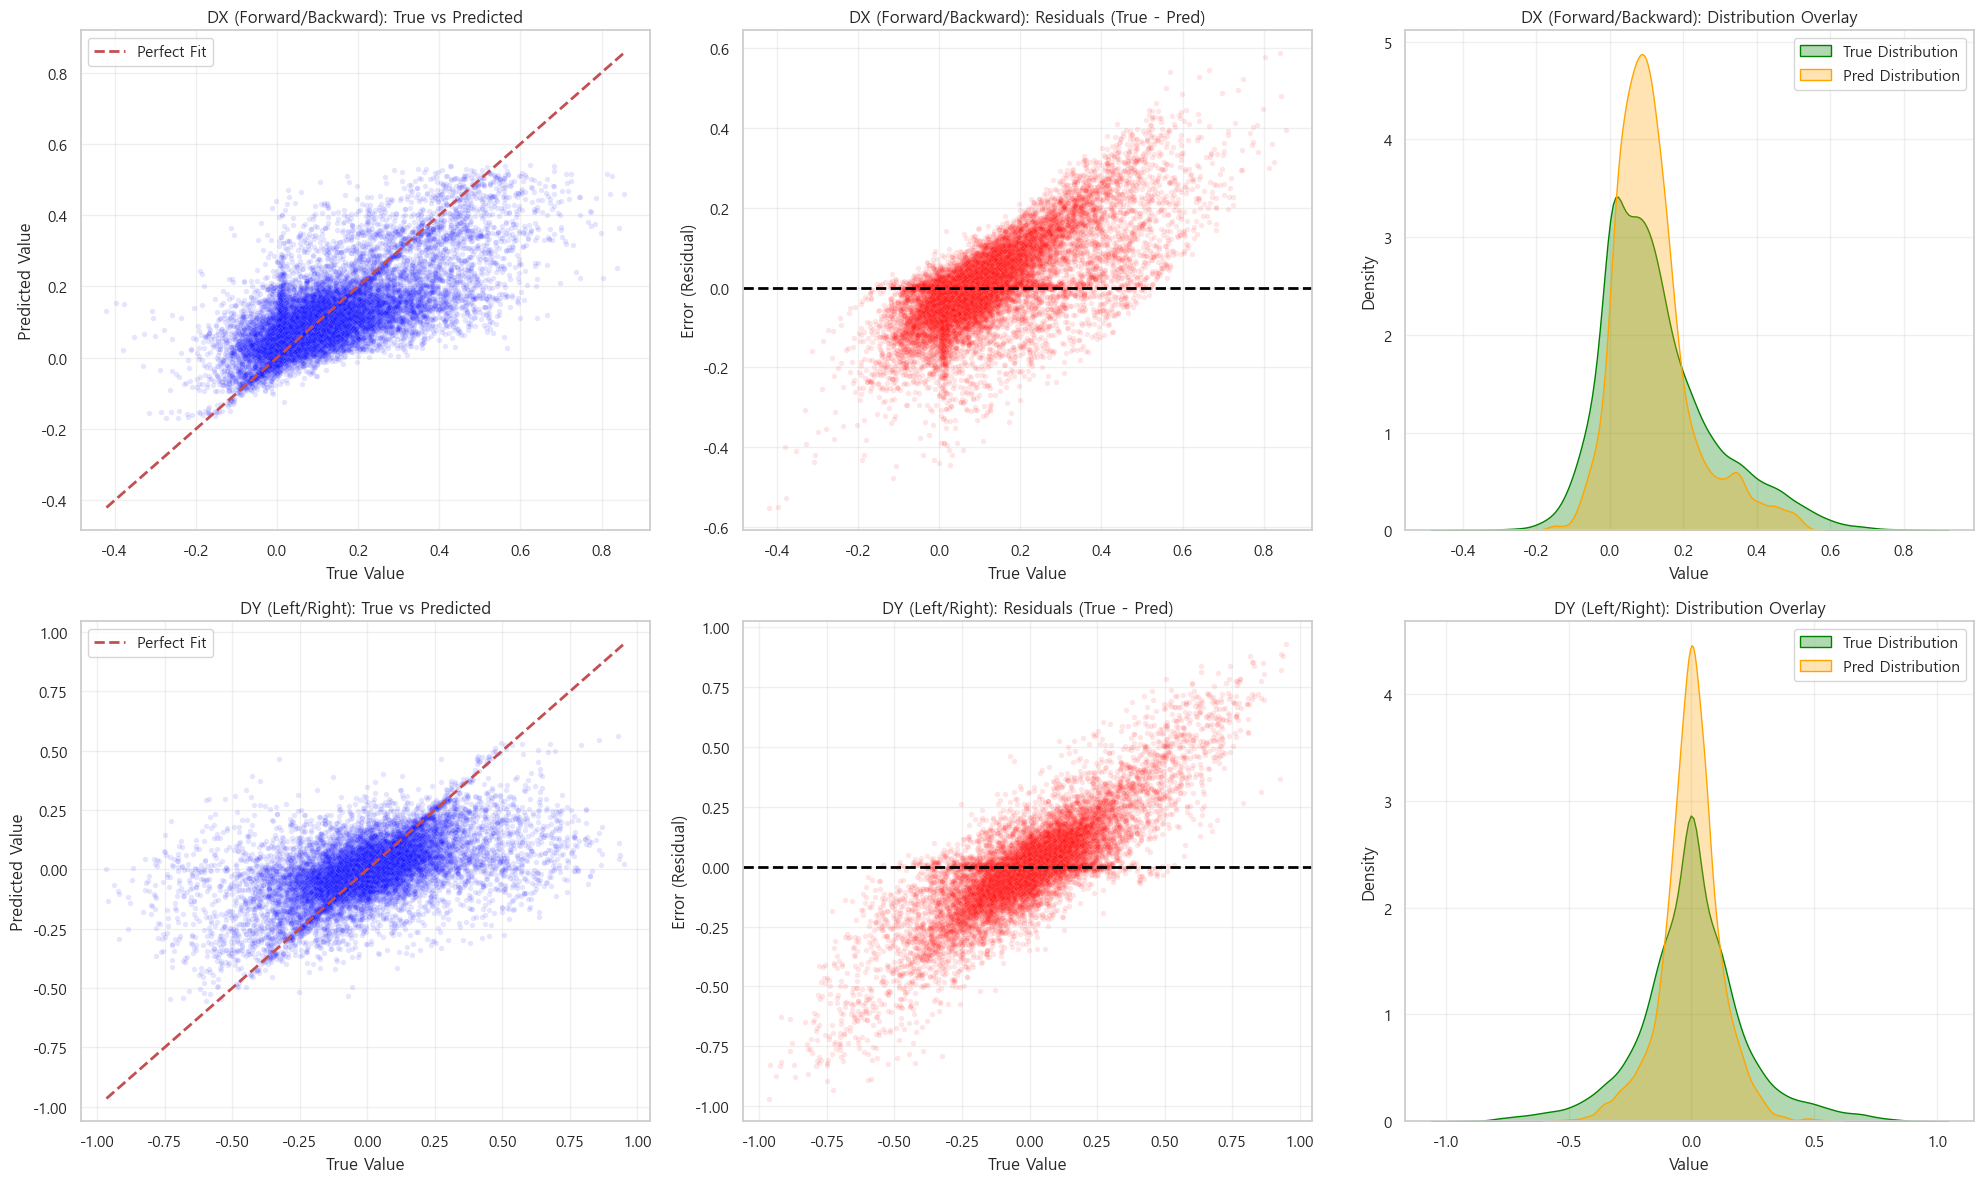

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_prediction_analysis(val_df, pred_dx, pred_dy):
    """
    DX, DY 각각에 대해 True vs Pred, Residual, Distribution을 시각화
    """
    
    # 캔버스 설정 (2행 3열)
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    targets = ['target_dx', 'target_dy']
    preds = [pred_dx, pred_dy]
    labels = ['DX (Forward/Backward)', 'DY (Left/Right)']
    
    for i in range(2): # 0: DX, 1: DY
        true = val_df[targets[i]]
        pred = preds[i]
        label = labels[i]
        
        # ---------------------------------------------------------
        # 1. Scatter Plot (True vs Pred) - 상관관계 확인
        # ---------------------------------------------------------
        ax = axes[i, 0]
        # 데이터가 많으므로 alpha를 낮춰서 밀도 확인
        sns.scatterplot(x=true, y=pred, alpha=0.1, s=15, ax=ax, color='blue')
        
        # 기준선 (Perfect Prediction Line y=x)
        min_val = min(true.min(), pred.min())
        max_val = max(true.max(), pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
        
        ax.set_title(f'{label}: True vs Predicted')
        ax.set_xlabel('True Value')
        ax.set_ylabel('Predicted Value')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # ---------------------------------------------------------
        # 2. Residual Plot (True vs Error) - 오차 패턴 확인
        # ---------------------------------------------------------
        ax = axes[i, 1]
        residuals = true - pred
        sns.scatterplot(x=true, y=residuals, alpha=0.1, s=15, ax=ax, color='red')
        
        # 기준선 (Zero Error Line y=0)
        ax.axhline(0, color='black', linestyle='--', lw=2)
        
        ax.set_title(f'{label}: Residuals (True - Pred)')
        ax.set_xlabel('True Value')
        ax.set_ylabel('Error (Residual)')
        ax.grid(True, alpha=0.3)
        
        # ---------------------------------------------------------
        # 3. Distribution Plot (True vs Pred) - 분포 모양 비교
        # ---------------------------------------------------------
        ax = axes[i, 2]
        sns.kdeplot(true, fill=True, label='True Distribution', color='green', alpha=0.3, ax=ax)
        sns.kdeplot(pred, fill=True, label='Pred Distribution', color='orange', alpha=0.3, ax=ax)
        
        ax.set_title(f'{label}: Distribution Overlay')
        ax.set_xlabel('Value')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- 실행 ---
# val_data: 검증 데이터프레임
# pred_dx, pred_dy: 모델이 예측한 결과 배열 (numpy array)
plot_prediction_analysis(df_data, oof_dx, oof_dy)

In [119]:
# 모델 저장 path
save_path_dx_mae = 'autogluon_EDA/model_dx_mae'
save_path_dy_mae = 'autogluon_EDA/model_dy_mae'

save_path_dx_quantile = 'autogluon_EDA/model_dx_quantile'
save_path_dy_quantile = 'autogluon_EDA/model_dy_quantile'

drop_cols = ['game_episode', 'true_end_x', 'true_end_y']

In [124]:
drop_dx_cols = ['target_dy']
drop_dx_cols += ['last_player_dy', 'plsx_pey_diff', 'grid_dy', 'visible_goal_angle', 'angle_to_goal', 'type_med_diff']
drop_dx_cols += ['start_xy_corr', 'g_start_x_75', 'g_start_y_25', 'pg_dx_25', 'window_dx_25','pg_dy_25']
drop_dx_cols += ['field_dy_dt_1', 'prev_field_speed_1', 'field_speed_0', 'field_speed_1', 'field_speed_2', 'prev_field_speed_3']
drop_dx_cols += ['prev_last_x_dt', 'field_speed_diff_1', 'field_speed_diff_2', 'prev_field_dx_speed_3']
drop_dx_cols += ['prev_type_grid_dy', 'last_type_name']

In [132]:
drop_dy_cols = ['target_dx']
drop_dy_cols += ['player_dy_dx_div','last_team_start_x', 'prev_team_start_x','pg_dy_75', 'cross_prod_0', 'cos_theta_0']
drop_dy_cols += ['prev_last_x_vel', 'prev_last_y_vel', 'center_dy_abs', 'center_dx_abs', 'prev_type_result', 'prev_dx_dt_div', 'prev_dy_dt_div']
drop_dy_cols += ['prev_dx_speed', 'prev_dy_speed', 'prev_dx_speed_abs', 'prev_dy_speed_abs', 'field_dx_dt_1']
drop_dy_cols += ['prev_field_speed_2', 'prev_last_y_dt', 'center_dx_dt', 'center_dy_dt', 'dist_to_center_speed']
drop_dy_cols += ['grid_dx', 'last_result_grid_dx']

In [128]:
# dx 예측 모델 학습
predictor_dx_mae = TabularPredictor(
    label='target_dx',
    path=save_path_dx_mae,
    eval_metric='mean_absolute_error',
).fit(
    train_data=df_data.drop(columns=drop_cols + drop_dx_cols),
    presets='best_quality',
    time_limit=60
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22631
CPU Count:          24
Memory Avail:       46.42 GB / 61.66 GB (75.3%)
Disk Space Avail:   1468.24 GB / 1862.19 GB (78.8%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdout validation data is

In [130]:
# dx 예측 모델 학습
predictor_dx_quantile = TabularPredictor(
    label='target_dx',
    path=save_path_dx_quantile,
    problem_type='quantile',
    quantile_levels=[0.2, 0.50, 0.80],
    eval_metric='pinball_loss',
).fit(
    train_data=df_data.drop(columns=drop_cols + drop_dx_cols),
    presets='best_quality',
    time_limit=60
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22631
CPU Count:          24
Memory Avail:       47.72 GB / 61.66 GB (77.4%)
Disk Space Avail:   1468.23 GB / 1862.19 GB (78.8%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdout validation data is

In [133]:
# dy 예측 모델 학습
predictor_dy_mae = TabularPredictor(
    label='target_dy', 
    path=save_path_dy_mae,
    eval_metric='mean_absolute_error',
).fit(
    train_data=df_data.drop(columns=drop_cols + drop_dy_cols),
    presets='best_quality',
    time_limit=60
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22631
CPU Count:          24
Memory Avail:       47.69 GB / 61.66 GB (77.3%)
Disk Space Avail:   1464.92 GB / 1862.19 GB (78.7%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdout validation data is

In [134]:
# dy 예측 모델 학습
predictor_dy_quantile = TabularPredictor(
    label='target_dy', 
    path=save_path_dy_quantile,
    problem_type='quantile',
    quantile_levels=[0.2, 0.50, 0.8],
    eval_metric='pinball_loss',
).fit(
    train_data=df_data.drop(columns=drop_cols + drop_dy_cols),
    presets='best_quality',
    time_limit=60
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.10.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22631
CPU Count:          24
Memory Avail:       47.29 GB / 61.66 GB (76.7%)
Disk Space Avail:   1464.10 GB / 1862.19 GB (78.6%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdout validation data is

In [135]:
# 검증 및 점수

pred_dx_mae = predictor_dx_mae.predict_oof()
pred_dy_mae = predictor_dy_mae.predict_oof()

pred_dx_df = predictor_dx_quantile.predict_oof()
pred_dy_df = predictor_dy_quantile.predict_oof()

pred_dx_m = pred_dx_df[0.50]
pred_dx_l = pred_dx_df[0.20]
pred_dx_h = pred_dx_df[0.80]

pred_dx = pred_dx_m.copy()

xwl = get_blend_weight(pred_dx_m, lower=-0.50, upper=-0.20, max_weight=0.13)
pred_dx = (pred_dx * (1 - xwl) + (pred_dx_l * xwl))

xwh = get_blend_weight(pred_dx_m, lower=0.05, upper=0.90, max_weight=0.43)
pred_dx = (pred_dx * (1 - xwh)) + (pred_dx_h * xwh)

pred_dy_m = pred_dy_df[0.50]
pred_dy_l = pred_dy_df[0.20]
pred_dy_h = pred_dy_df[0.80]

pred_dy = pred_dy_m.copy()

ywl = get_blend_weight(pred_dy_m, lower=-0.41, upper=-0.60, max_weight=0.90)
pred_dy = (pred_dy * (1 - ywl) + (pred_dy_l * ywl))

ywh = get_blend_weight(pred_dy_m, lower=0.22, upper=1.20, max_weight=1.10)
pred_dy = (pred_dy * (1 - ywh) + (pred_dy_h * ywh))

ratio = 0.82
pred_dx = (pred_dx * ratio) + (pred_dx_mae * (1-ratio))
pred_dy = (pred_dy * ratio) + (pred_dy_mae * (1-ratio))

# 절대 좌표로 복원
pred_end_x = (df_data['last_start_x'] + pred_dx) * 105
pred_end_y = (df_data['last_start_y'] + pred_dy) * 68

# 경기장 범위 밖으로 나간 예측값 보정
pred_end_x = pred_end_x.clip(0, 105)
pred_end_y = pred_end_y.clip(0, 68)

# 실제 정답
true_end_x = df_data['true_end_x'] * 105
true_end_y = df_data['true_end_y'] * 68

# 거리 계산
euclidean_dist = np.sqrt((pred_end_x - true_end_x)**2 + (pred_end_y - true_end_y)**2)
final_score = euclidean_dist.mean()
print(f"# 최종 검증 점수: {final_score:.4f}")

# 최종 검증 점수: 12.7373


In [136]:
# x 모델 피처 중요도
importance_quantile_x = predictor_dx_quantile.feature_importance(df_data.drop(columns=drop_cols + drop_dx_cols))
print(importance_quantile_x)

These features in provided data are not utilized by the predictor and will be ignored: ['field_dy_1', 'field_dx_3']
Computing feature importance via permutation shuffling for 106 features using 5000 rows with 5 shuffle sets...
	5174.76s	= Expected runtime (1034.95s per shuffle set)
	3456.32s	= Actual runtime (Completed 5 of 5 shuffle sets)


                     importance        stddev       p_value  n  p99_high  \
field_dist_3           0.004801  9.746008e-05  2.036005e-08  5  0.005002   
grid_dx                0.003737  2.931876e-04  4.509021e-06  5  0.004341   
last_result_grid_dx    0.003328  1.405126e-04  3.804482e-07  5  0.003617   
prev_type_result       0.002470  8.414057e-05  1.612976e-07  5  0.002643   
prev_dx_dt_div         0.002229  1.256322e-04  1.206951e-06  5  0.002487   
...                         ...           ...           ... ..       ...   
prev_is_home           0.000065  2.048348e-06  1.164117e-07  5  0.000069   
last_start_y           0.000060  9.587970e-07  7.995764e-09  5  0.000062   
field_dy_2             0.000055  2.091738e-06  2.582817e-07  5  0.000059   
field_dy_0             0.000054  2.095778e-06  2.778170e-07  5  0.000058   
field_dy_3             0.000051  5.935305e-07  2.225876e-09  5  0.000052   

                      p99_low  
field_dist_3         0.004601  
grid_dx              0.

In [137]:
# x 모델 피처 중요도
importance_mae_x = predictor_dx_mae.feature_importance(df_data.drop(columns=drop_cols + drop_dx_cols))
print(importance_mae_x)

These features in provided data are not utilized by the predictor and will be ignored: ['field_dy_1', 'field_dx_3']
Computing feature importance via permutation shuffling for 106 features using 5000 rows with 5 shuffle sets...
	308.3s	= Expected runtime (61.66s per shuffle set)
	58.73s	= Actual runtime (Completed 5 of 5 shuffle sets)


                     importance    stddev       p_value  n  p99_high   p99_low
field_dist_3           0.012315  0.000086  2.872978e-10  5  0.012492  0.012137
grid_dx                0.008836  0.000661  3.719624e-06  5  0.010197  0.007476
last_result_grid_dx    0.007748  0.000323  3.596008e-07  5  0.008412  0.007083
prev_type_result       0.006166  0.000297  6.401838e-07  5  0.006777  0.005555
prev_dx_dt_div         0.005865  0.000412  2.895013e-06  5  0.006713  0.005018
...                         ...       ...           ... ..       ...       ...
last_start_y           0.000150  0.000010  1.943594e-06  5  0.000169  0.000130
field_dy_0             0.000146  0.000004  5.858302e-08  5  0.000154  0.000138
prev_last_dy           0.000136  0.000012  6.523201e-06  5  0.000160  0.000112
field_dy_2             0.000135  0.000005  2.855085e-07  5  0.000146  0.000125
field_dy_3             0.000124  0.000004  1.194522e-07  5  0.000133  0.000116

[106 rows x 6 columns]


In [138]:
# y 모델 피처 중요도
importance_quantile_y = predictor_dy_quantile.feature_importance(df_data.drop(columns=drop_cols + drop_dy_cols))
print(importance_quantile_y)

These features in provided data are not utilized by the predictor and will be ignored: ['field_dy_1', 'field_dx_3']
Computing feature importance via permutation shuffling for 105 features using 5000 rows with 5 shuffle sets...
	935.21s	= Expected runtime (187.04s per shuffle set)
	359.65s	= Actual runtime (Completed 5 of 5 shuffle sets)


                  importance    stddev       p_value  n  p99_high   p99_low
prev_last_dy        0.005159  0.000085  8.916378e-09  5  0.005334  0.004983
prev_sin            0.001976  0.000144  3.369961e-06  5  0.002272  0.001679
last_result_name    0.001849  0.000072  2.751350e-07  5  0.001998  0.001701
prev_dy             0.001824  0.000089  6.670765e-07  5  0.002006  0.001641
dist_to_center      0.001748  0.000071  3.219167e-07  5  0.001894  0.001603
...                      ...       ...           ... ..       ...       ...
field_dx_0          0.000104  0.000010  1.215215e-05  5  0.000125  0.000082
center_dx           0.000100  0.000007  2.935966e-06  5  0.000115  0.000086
field_dx_2          0.000095  0.000008  4.680871e-06  5  0.000110  0.000079
field_dx_1          0.000090  0.000007  4.984770e-06  5  0.000105  0.000075
last_type_name      0.000000  0.000000  5.000000e-01  5  0.000000  0.000000

[105 rows x 6 columns]


In [139]:
# y 모델 피처 중요도
importance_mae_y = predictor_dy_mae.feature_importance(df_data.drop(columns=drop_cols + drop_dy_cols))
print(importance_mae_y)

These features in provided data are not utilized by the predictor and will be ignored: ['field_dy_1', 'field_dx_3']
Computing feature importance via permutation shuffling for 105 features using 5000 rows with 5 shuffle sets...
	564.48s	= Expected runtime (112.9s per shuffle set)
	87.93s	= Actual runtime (Completed 5 of 5 shuffle sets)


                    importance        stddev       p_value  n      p99_high  \
prev_last_dy      1.325711e-02  3.920859e-04  9.170751e-08  5  1.406442e-02   
prev_sin          1.311766e-02  4.533418e-04  1.709102e-07  5  1.405109e-02   
prev_result_name  8.242929e-03  3.979009e-04  6.495411e-07  5  9.062213e-03   
dist_to_center    8.190097e-03  3.046044e-04  2.291761e-07  5  8.817281e-03   
grid_dy           7.304394e-03  5.908914e-04  5.094425e-06  5  8.521048e-03   
...                        ...           ...           ... ..           ...   
last_start_x      3.643011e-04  4.651640e-05  3.121628e-05  5  4.600790e-04   
field_dx_0        3.639659e-04  3.045148e-05  5.825450e-06  5  4.266659e-04   
field_dx_1        3.338256e-04  9.884833e-06  9.214513e-08  5  3.541786e-04   
field_dx_2        3.218329e-04  2.137614e-05  2.321806e-06  5  3.658467e-04   
last_type_name    1.258552e-08  1.723343e-08  8.890390e-02  5  4.806940e-08   

                       p99_low  
prev_last_dy      